In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize
import statsmodels.api as sm

In [8]:
casas = {
    "R1":"casa1PM.xlsx",
    "R2":"casa2PM.xlsx",
    "R3":"casa3PM.xlsx",
    "R4":"casa4PM.xlsx"
}

fracoes = {
    "MP1":("cinPM1","coutPM1"),
    "MP2.5":("cinPM25","coutPM25"),
    "MP10":("cinPM10","coutPM10")
}

block_sizes = [4,6,8,12]
n_boots = [200,500,1000]
frac_values = [0.4,0.5,0.6,0.7]



In [9]:
def classificar_origem(Cin, Cout, Cin_lag, Cout_lag,
                       ratio_th=1.2,
                       diff_in=3,
                       diff_ext=2):

    eps = 1e-6

    if (
        ((Cin/(Cout+eps)) > ratio_th and
         (Cin-Cin_lag) > diff_in and
         (Cout-Cout_lag) < diff_ext)
        or Cin > 45
    ):
        return "interno"

    elif (Cin/(Cout+eps)) < ratio_th or Cin <= Cout:
        return "externo"

    else:
        return "desconhecido"

In [10]:
def moving_block_bootstrap(x, y, block_size):

    n = len(x)
    idx = np.arange(n - block_size)

    xs = []
    ys = []

    while len(xs) < n:

        start = np.random.choice(idx)
        block = slice(start, start + block_size)

        xs.extend(x[block])
        ys.extend(y[block])

    return np.array(xs[:n]), np.array(ys[:n])

In [11]:
def simular_mbm(Finf, k, Cout, Cin0):

    Cin_pred = np.zeros(len(Cout))
    Cin_pred[0] = Cin0

    for t in range(1,len(Cout)):
        Cin_pred[t] = Finf*Cout[t] + (Cin_pred[t-1] - Finf*Cout[t])*np.exp(-k)

    return Cin_pred

In [12]:
def ajustar_mbm(Cin, Cout):

    def erro(params):

        Finf,k = params

        if not (0 < Finf < 1 and k > 0):
            return np.inf

        pred = simular_mbm(Finf,k,Cout,Cin[0])

        return np.sqrt(np.mean((Cin - pred)**2))

    res = minimize(erro,[0.5,0.3],bounds=[(0.001,0.999),(0.001,3)])

    return res.x

In [13]:
def ajustar_lowess(Cin, Cout, frac):

    ratio = Cin/Cout

    smooth = sm.nonparametric.lowess(
        ratio,
        Cout,
        frac=frac,
        return_sorted=False
    )

    Finf = np.clip(np.mean(smooth),0,1)

    pred = Finf*Cout

    return Finf,pred

In [14]:
def astm_d5157(obs, mod):

    mask = np.isfinite(obs) & np.isfinite(mod)

    obs = obs[mask]
    mod = mod[mask]

    r = np.corrcoef(obs,mod)[0,1]

    a,b = np.polyfit(obs,mod,1)

    nmse = np.mean((mod-obs)**2)/(np.mean(mod)*np.mean(obs))

    fb = 2*(np.mean(mod)-np.mean(obs))/(np.mean(mod)+np.mean(obs))

    fs = 2*(np.std(mod)-np.std(obs))/(np.std(mod)+np.std(obs))

    return {"r":r,"a":a,"b":b,"NMSE":nmse,"FB":fb,"FS":fs}

In [15]:
resultados_tabela = []
resultados_series = {}

for casa_label, arquivo in casas.items():

    print(f"\n====================")
    print(f"Casa: {casa_label}")
    print(f"====================")

    df = pd.read_excel(arquivo)
    resultados_series[casa_label] = {}

    for frac_label, (cin_col, cout_col) in fracoes.items():

        print(f"\nFração: {frac_label}")

        # ==================================================
        # 1. PRÉ-PROCESSAMENTO
        # ==================================================
        Cin_full = df[cin_col].values.astype(float)
        Cout_full = df[cout_col].values.astype(float)

        # remoção/correção simples de outliers em Cout
        q1, q3 = np.percentile(Cout_full, [25, 75])
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        Cout_corr = Cout_full.copy()
        Cout_corr[(Cout_corr < lim_inf) | (Cout_corr > lim_sup)] = np.nan
        Cout_corr = pd.Series(Cout_corr).interpolate().bfill().ffill().values

        # lags para censura
        Cin_lag = np.roll(Cin_full, 1)
        Cin_lag[0] = Cin_full[0]

        Cout_lag = np.roll(Cout_corr, 1)
        Cout_lag[0] = Cout_corr[0]

        # classificar origem
        classes = [
            classificar_origem(Cin_full[i], Cout_corr[i], Cin_lag[i], Cout_lag[i])
            for i in range(len(Cin_full))
        ]

        mask_ext = np.array(classes) == "externo"

        Cin = Cin_full[mask_ext]
        Cout = Cout_corr[mask_ext]

        mask_valid = np.isfinite(Cin) & np.isfinite(Cout) & (Cout > 0)
        Cin = Cin[mask_valid]
        Cout = Cout[mask_valid]

        if len(Cin) < 20:
            print("Poucos dados externos válidos. Pulando.")
            continue

        # ==================================================
        # 2. BUSCA DE HIPERPARÂMETROS - MBM
        # ==================================================
        melhor_rmse_mbm = np.inf
        melhor_config_mbm = None
        melhor_finf_vals_mbm = None
        melhor_k_vals_mbm = None

        for block_size in block_sizes:
            for n_boot in n_boots:

                rmses_boot = []
                Finf_vals_boot = []
                k_vals_boot = []

                for _ in range(n_boot):

                    Cout_b, Cin_b = moving_block_bootstrap(Cout, Cin, block_size)

                    try:
                        Finf_b, k_b = ajustar_mbm(Cin_b, Cout_b)
                        pred_b = simular_mbm(Finf_b, k_b, Cout_b, Cin_b[0])
                        rmse_b = np.sqrt(mean_squared_error(Cin_b, pred_b))

                        rmses_boot.append(rmse_b)
                        Finf_vals_boot.append(Finf_b)
                        k_vals_boot.append(k_b)

                    except Exception:
                        continue

                if len(rmses_boot) == 0:
                    continue

                rmse_mean = np.mean(rmses_boot)

                if rmse_mean < melhor_rmse_mbm:
                    melhor_rmse_mbm = rmse_mean
                    melhor_config_mbm = {
                        "block_size": block_size,
                        "n_boot": n_boot
                    }
                    melhor_finf_vals_mbm = np.array(Finf_vals_boot)
                    melhor_k_vals_mbm = np.array(k_vals_boot)

        print("Melhor configuração MBM:", melhor_config_mbm)

        # ==================================================
        # 2. BUSCA DE HIPERPARÂMETROS - LOWESS
        # ==================================================
        melhor_rmse_low = np.inf
        melhor_config_low = None
        melhor_finf_vals_low = None

        for block_size in block_sizes:
            for n_boot in n_boots:
                for frac in frac_values:

                    rmses_boot = []
                    Finf_vals_boot = []

                    for _ in range(n_boot):

                        Cout_b, Cin_b = moving_block_bootstrap(Cout, Cin, block_size)

                        try:
                            Finf_b, pred_b = ajustar_lowess(Cin_b, Cout_b, frac)
                            rmse_b = np.sqrt(mean_squared_error(Cin_b, pred_b))

                            rmses_boot.append(rmse_b)
                            Finf_vals_boot.append(Finf_b)

                        except Exception:
                            continue

                    if len(rmses_boot) == 0:
                        continue

                    rmse_mean = np.mean(rmses_boot)

                    if rmse_mean < melhor_rmse_low:
                        melhor_rmse_low = rmse_mean
                        melhor_config_low = {
                            "block_size": block_size,
                            "n_boot": n_boot,
                            "frac": frac
                        }
                        melhor_finf_vals_low = np.array(Finf_vals_boot)

        print("Melhor configuração LOWESS:", melhor_config_low)

        # segurança
        if melhor_config_mbm is None or melhor_config_low is None:
            print("Não foi possível encontrar hiperparâmetros válidos. Pulando.")
            continue

        # ==================================================
        # 3. VALIDAÇÃO TEMPORAL COM HIPERPARÂMETROS ÓTIMOS
        # ==================================================
        tscv = TimeSeriesSplit(n_splits=5)

        pred_mbm = np.full(len(Cin), np.nan)
        pred_low = np.full(len(Cin), np.nan)

        Finf_folds_mbm = []
        k_folds_mbm = []
        Finf_folds_low = []

        for train_idx, test_idx in tscv.split(Cin):

            Cin_train, Cin_test = Cin[train_idx], Cin[test_idx]
            Cout_train, Cout_test = Cout[train_idx], Cout[test_idx]

            # ---------- MBM ----------
            try:
                Finf_mbm, k_mbm = ajustar_mbm(Cin_train, Cout_train)
                pred_test_mbm = simular_mbm(Finf_mbm, k_mbm, Cout_test, Cin_train[-1])

                pred_mbm[test_idx] = pred_test_mbm
                Finf_folds_mbm.append(Finf_mbm)
                k_folds_mbm.append(k_mbm)

            except Exception:
                pass

            # ---------- LOWESS ----------
            try:
                Finf_low, pred_train_dummy = ajustar_lowess(
                    Cin_train,
                    Cout_train,
                    melhor_config_low["frac"]
                )

                pred_test_low = Finf_low * Cout_test
                pred_low[test_idx] = pred_test_low
                Finf_folds_low.append(Finf_low)

            except Exception:
                pass

        # ==================================================
        # 4. MÉTRICAS FINAIS
        # ==================================================
        # MBM
        mask_mbm = np.isfinite(Cin) & np.isfinite(pred_mbm)

        if np.sum(mask_mbm) > 5:
            rmse_mbm = np.sqrt(mean_squared_error(Cin[mask_mbm], pred_mbm[mask_mbm]))
            r2_mbm = r2_score(Cin[mask_mbm], pred_mbm[mask_mbm])
            astm_mbm = astm_d5157(Cin[mask_mbm], pred_mbm[mask_mbm])

            resultados_tabela.append({
                "Casa": casa_label,
                "Fração": frac_label,
                "Modelo": "MBM",
                "RMSE": rmse_mbm,
                "R²": r2_mbm,
                "r": astm_mbm["r"],
                "a": astm_mbm["a"],
                "b": astm_mbm["b"],
                "NMSE": astm_mbm["NMSE"],
                "FB": astm_mbm["FB"],
                "FS": astm_mbm["FS"],
                "Finf_mean": np.mean(melhor_finf_vals_mbm),
                "Finf_std": np.std(melhor_finf_vals_mbm),
                "Finf_IC95_min": np.percentile(melhor_finf_vals_mbm, 2.5),
                "Finf_IC95_max": np.percentile(melhor_finf_vals_mbm, 97.5),
                "k_mean": np.mean(melhor_k_vals_mbm),
                "k_std": np.std(melhor_k_vals_mbm),
                "best_block_size": melhor_config_mbm["block_size"],
                "best_n_boot": melhor_config_mbm["n_boot"]
            })

            resultados_series[casa_label][(frac_label, "MBM")] = {
                "Cin_obs": Cin,
                "Cin_pred": pred_mbm,
                "Finf_vals": melhor_finf_vals_mbm,
                "k_vals": melhor_k_vals_mbm,
                "Finf_folds": np.array(Finf_folds_mbm),
                "k_folds": np.array(k_folds_mbm),
                "best_config": melhor_config_mbm
            }

        # LOWESS
        mask_low = np.isfinite(Cin) & np.isfinite(pred_low)

        if np.sum(mask_low) > 5:
            rmse_low = np.sqrt(mean_squared_error(Cin[mask_low], pred_low[mask_low]))
            r2_low = r2_score(Cin[mask_low], pred_low[mask_low])
            astm_low = astm_d5157(Cin[mask_low], pred_low[mask_low])

            resultados_tabela.append({
                "Casa": casa_label,
                "Fração": frac_label,
                "Modelo": "LOWESS",
                "RMSE": rmse_low,
                "R²": r2_low,
                "r": astm_low["r"],
                "a": astm_low["a"],
                "b": astm_low["b"],
                "NMSE": astm_low["NMSE"],
                "FB": astm_low["FB"],
                "FS": astm_low["FS"],
                "Finf_mean": np.mean(melhor_finf_vals_low),
                "Finf_std": np.std(melhor_finf_vals_low),
                "Finf_IC95_min": np.percentile(melhor_finf_vals_low, 2.5),
                "Finf_IC95_max": np.percentile(melhor_finf_vals_low, 97.5),
                "best_block_size": melhor_config_low["block_size"],
                "best_n_boot": melhor_config_low["n_boot"],
                "best_frac": melhor_config_low["frac"]
            })

            resultados_series[casa_label][(frac_label, "LOWESS")] = {
                "Cin_obs": Cin,
                "Cin_pred": pred_low,
                "Finf_vals": melhor_finf_vals_low,
                "Finf_folds": np.array(Finf_folds_low),
                "best_config": melhor_config_low
            }

# dataframe final
df_resultados = pd.DataFrame(resultados_tabela)
print(df_resultados)


Casa: R1

Fração: MP1
Melhor configuração MBM: {'block_size': 12, 'n_boot': 1000}
Melhor configuração LOWESS: {'block_size': 6, 'n_boot': 200, 'frac': 0.6}

Fração: MP2.5
Melhor configuração MBM: {'block_size': 8, 'n_boot': 500}
Melhor configuração LOWESS: {'block_size': 4, 'n_boot': 200, 'frac': 0.4}

Fração: MP10
Melhor configuração MBM: {'block_size': 12, 'n_boot': 200}
Melhor configuração LOWESS: {'block_size': 4, 'n_boot': 500, 'frac': 0.6}

Casa: R2

Fração: MP1
Melhor configuração MBM: {'block_size': 12, 'n_boot': 200}


c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.

Melhor configuração LOWESS: {'block_size': 6, 'n_boot': 200, 'frac': 0.4}

Fração: MP2.5


c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


Melhor configuração MBM: {'block_size': 12, 'n_boot': 500}
Melhor configuração LOWESS: {'block_size': 12, 'n_boot': 200, 'frac': 0.5}

Fração: MP10
Melhor configuração MBM: {'block_size': 12, 'n_boot': 1000}
Melhor configuração LOWESS: {'block_size': 12, 'n_boot': 200, 'frac': 0.5}

Casa: R3

Fração: MP1
Melhor configuração MBM: {'block_size': 12, 'n_boot': 1000}
Melhor configuração LOWESS: {'block_size': 12, 'n_boot': 500, 'frac': 0.4}

Fração: MP2.5
Melhor configuração MBM: {'block_size': 12, 'n_boot': 1000}
Melhor configuração LOWESS: {'block_size': 12, 'n_boot': 200, 'frac': 0.4}

Fração: MP10
Melhor configuração MBM: {'block_size': 6, 'n_boot': 500}
Melhor configuração LOWESS: {'block_size': 12, 'n_boot': 200, 'frac': 0.4}

Casa: R4

Fração: MP1
Melhor configuração MBM: {'block_size': 8, 'n_boot': 200}
Melhor configuração LOWESS: {'block_size': 6, 'n_boot': 200, 'frac': 0.7}

Fração: MP2.5
Melhor configuração MBM: {'block_size': 12, 'n_boot': 500}
Melhor configuração LOWESS: {'blo

In [ ]:
df_resultados = pd.DataFrame(resultados_tabela)
df_resultados = df_resultados.sort_values(["Fração", "Casa", "Modelo"]).reset_index(drop=True)

print("\n===== TABELA FINAL =====")
print(df_resultados)

df_resultados.to_excel("resultados_MBM_LOWESS.xlsx", index=False)

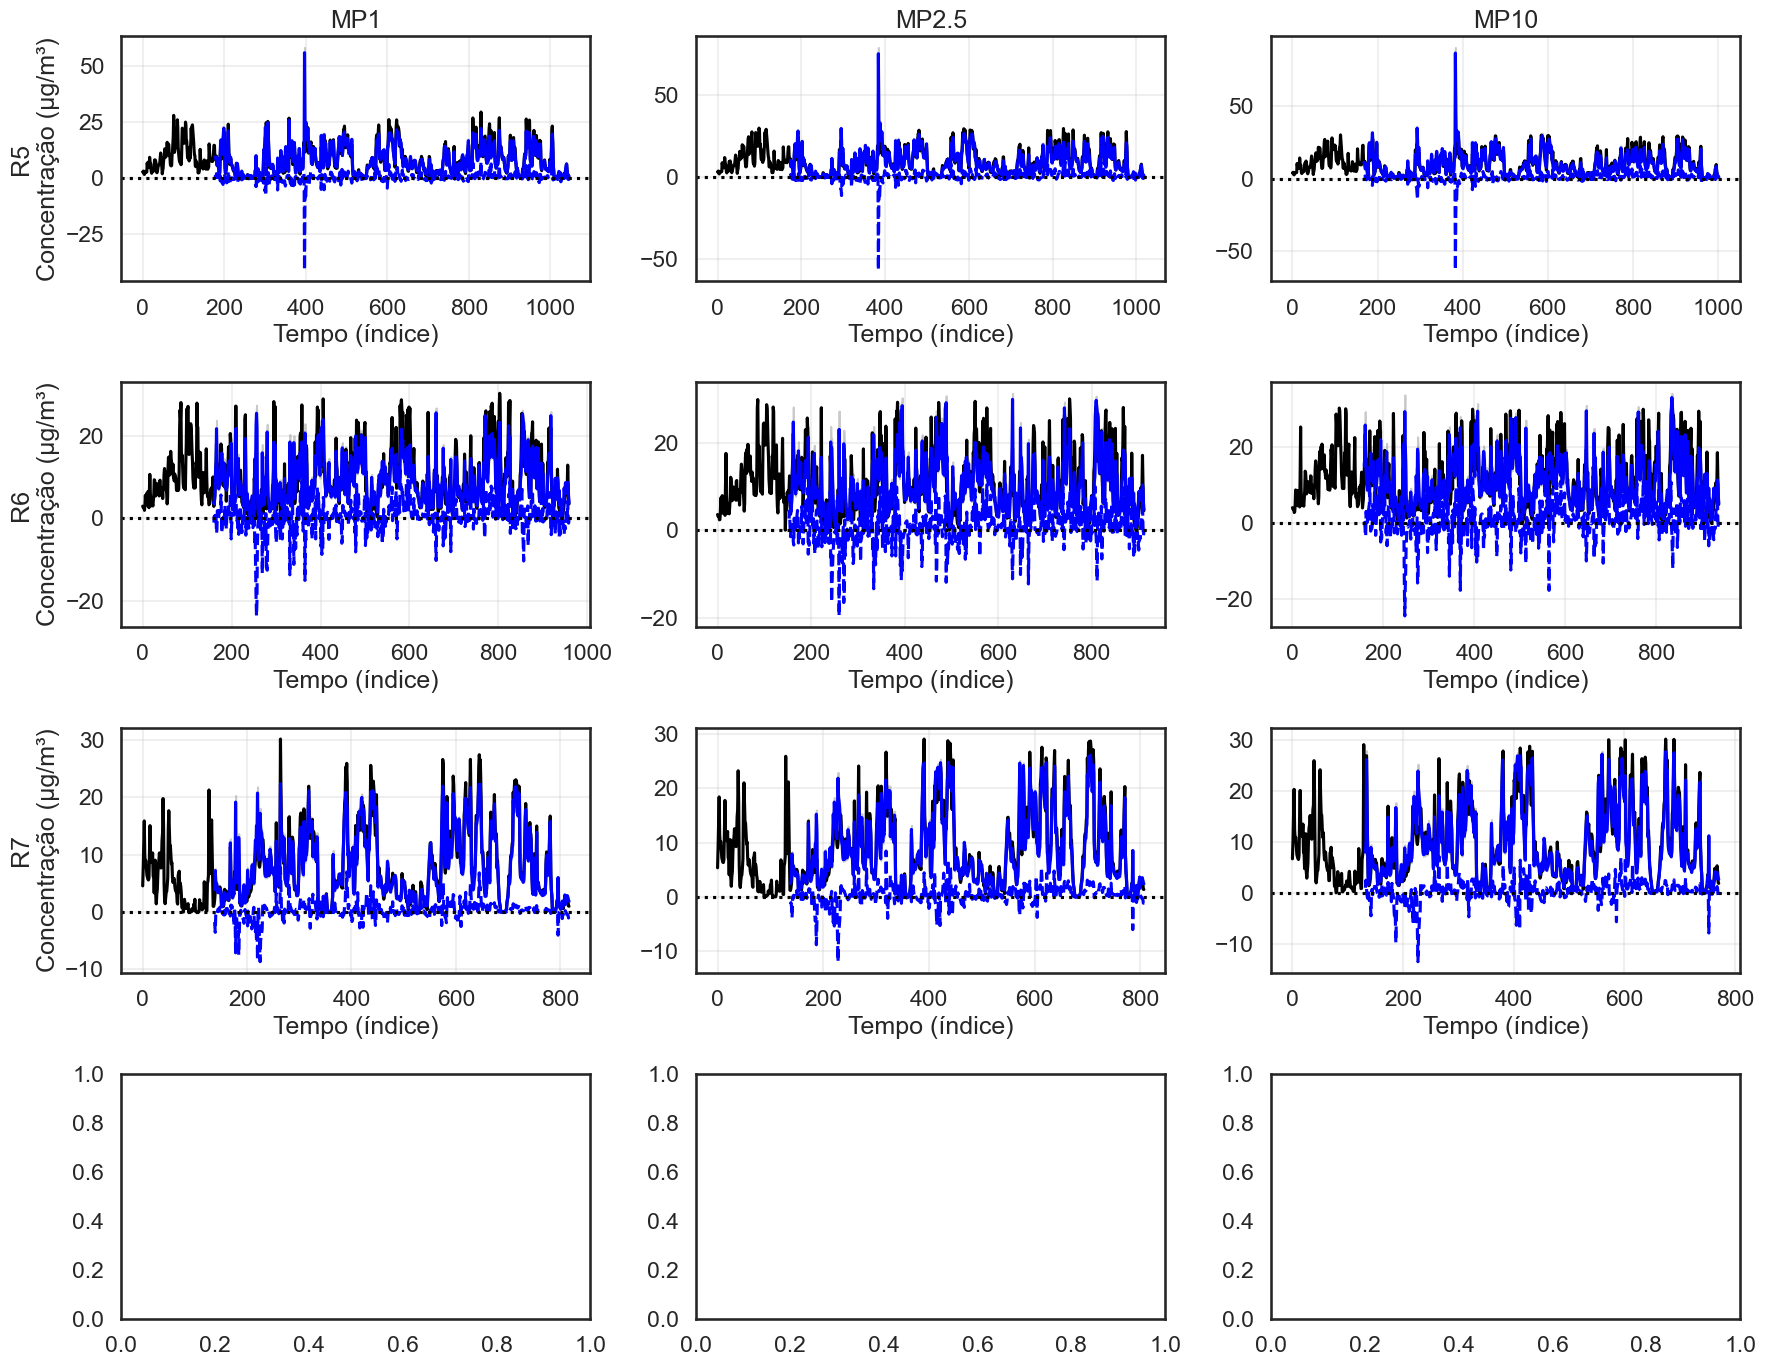

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, casa in enumerate(["R1","R2","R3","R4"]):
    for j, frac in enumerate(["MP1","MP2.5","MP10"]):

        ax = axs[i, j]

        key = (frac, "MBM")
        if key not in resultados_series[casa]:
            ax.axis("off")
            continue

        dados = resultados_series[casa][key]

        Cin = dados["Cin_obs"]
        Cin_ext = dados["Cin_pred"]
        Cin_std = dados["Cin_std"]

        temp = np.arange(len(Cin))

        Cin_int = Cin - Cin_ext

        ax.plot(temp, Cin, color="black", label="Cin observado")
        ax.plot(temp, Cin_ext, color="blue", label="Cin externo")

        ax.fill_between(temp,
                        Cin_ext - Cin_std,
                        Cin_ext + Cin_std,
                        color="gray", alpha=0.4, label="±1σ")

        ax.plot(temp, Cin_int, color="blue", linestyle="--", label="Cin interno")

        ax.axhline(0, linestyle=":", color="black")

        if i == 0:
            ax.set_title(frac)

        if j == 0:
            ax.set_ylabel(f"{casa}\nConcentração (µg/m³)")

        ax.set_xlabel("Tempo (índice)")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

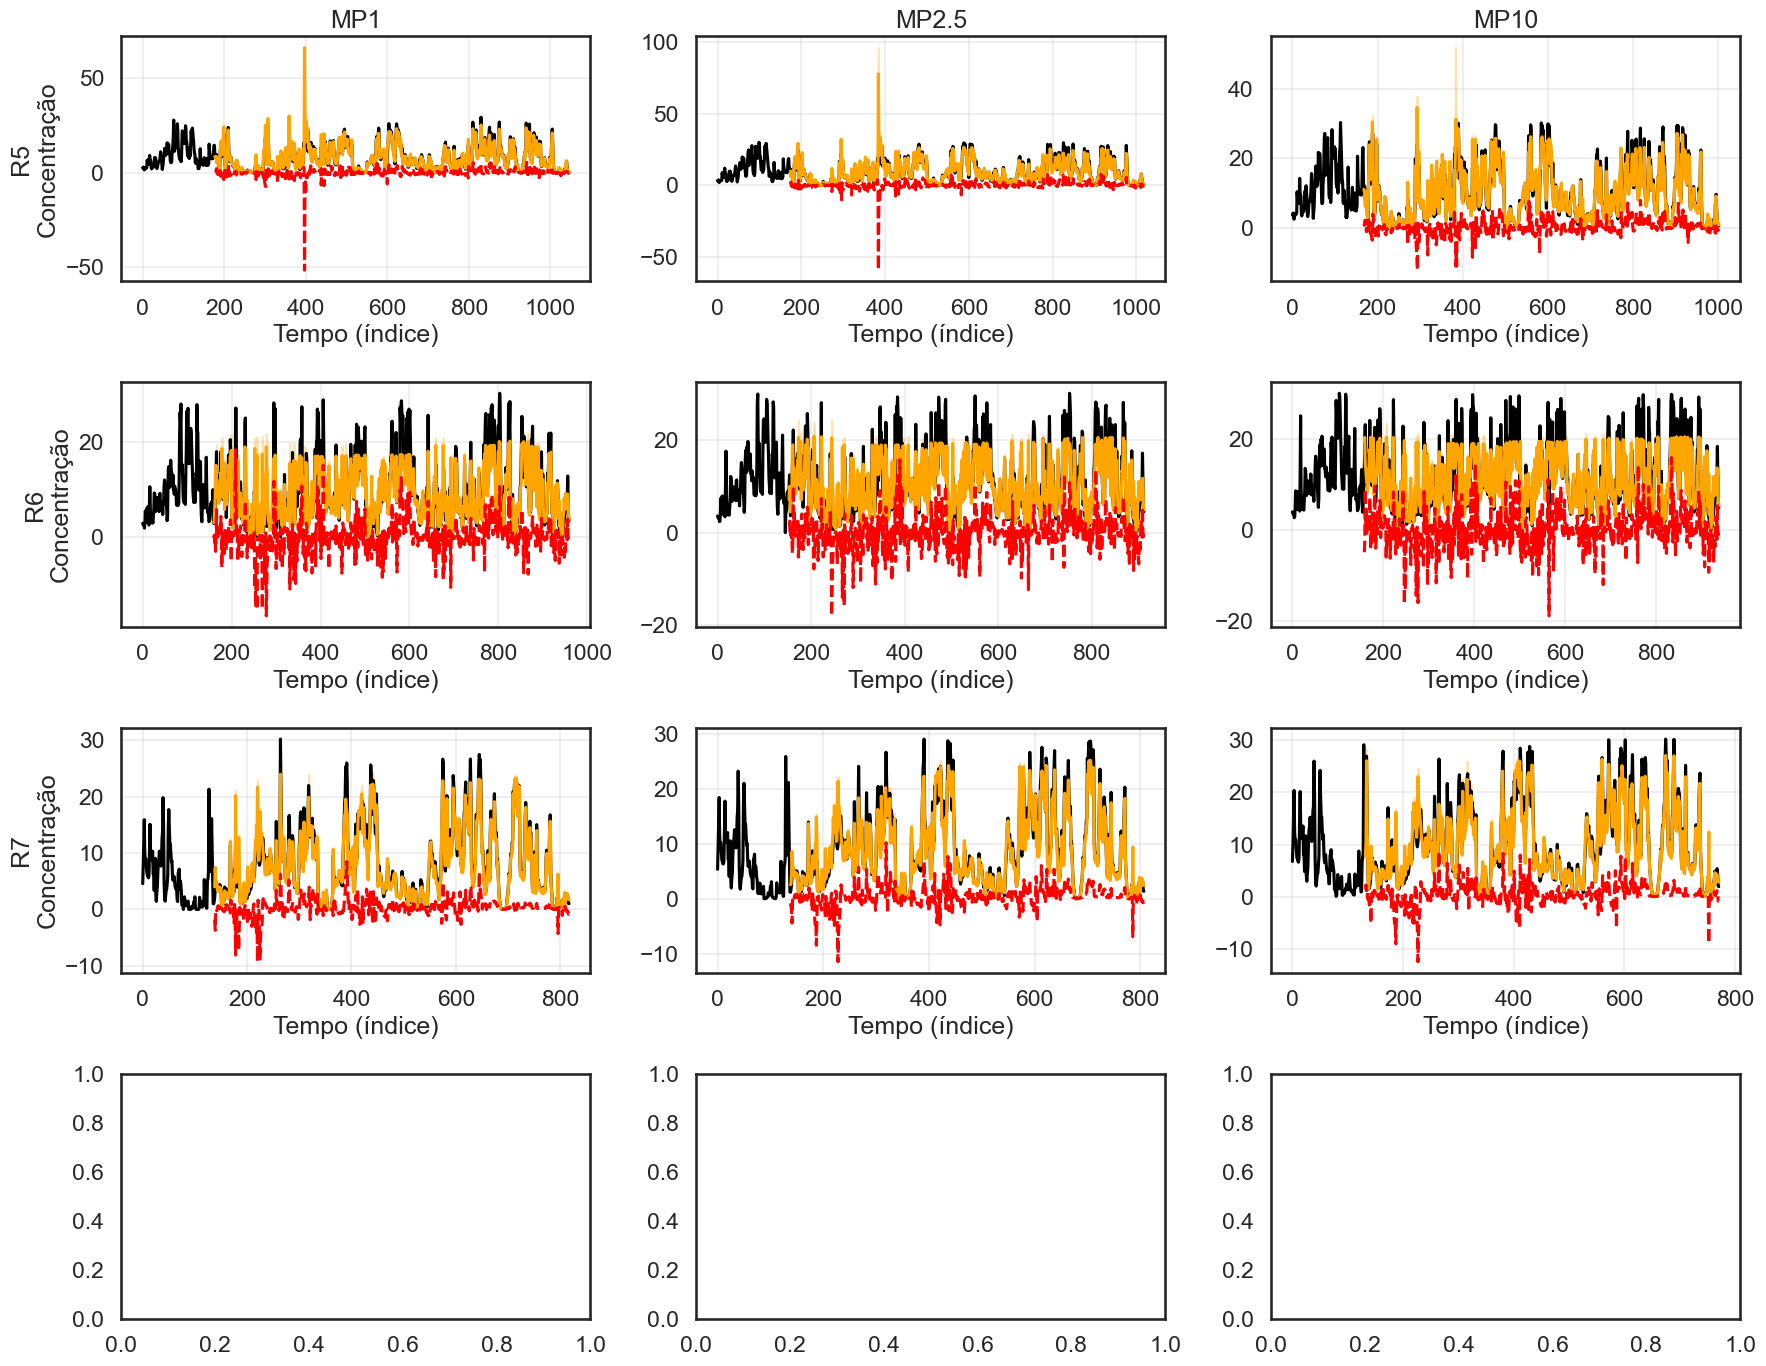

In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, casa in enumerate(["R1","R2","R3","R4"]): #["R1","R2","R3","R4"]
    for j, frac in enumerate(["MP1","MP2.5","MP10"]):

        ax = axs[i, j]

        key = (frac, "LOWESS")
        if key not in resultados_series[casa]:
            ax.axis("off")
            continue

        dados = resultados_series[casa][key]

        Cin = dados["Cin_obs"]
        Cin_ext = dados["Cin_pred"]
        Cin_std = dados["Cin_std"]

        tempo = np.arange(len(Cin))

        Cin_int = Cin - Cin_ext

        ax.plot(tempo, Cin, color="black", label="Cin observado")
        ax.plot(tempo, Cin_ext, color="orange", label="Cin_ext LOWESS")

        ax.fill_between(tempo,
                        Cin_ext - Cin_std,
                        Cin_ext + Cin_std,
                        color="orange", alpha=0.3, label="±1σ")

        ax.plot(tempo, Cin_int, color="red", linestyle="--", label="Cin_int LOWESS")

        if i == 0:
            ax.set_title(frac)

        if j == 0:
            ax.set_ylabel(f"{casa}\nConcentração")

        ax.set_xlabel("Tempo (índice)")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\melin\AppData\Local\Temp\ipykernel_5364\41751355.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([erros_train, erros_test],
C:\Users\melin\AppData\Local\Temp\ipykernel_5364\41751355.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([erros_train, erros_test],
C:\Users\melin\AppData\Local\Temp\ipykernel_5364\41751355.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([erros_train, erros_test],
C:\Users\melin\AppData\Local\Temp\ipykernel_5364\41751355.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib

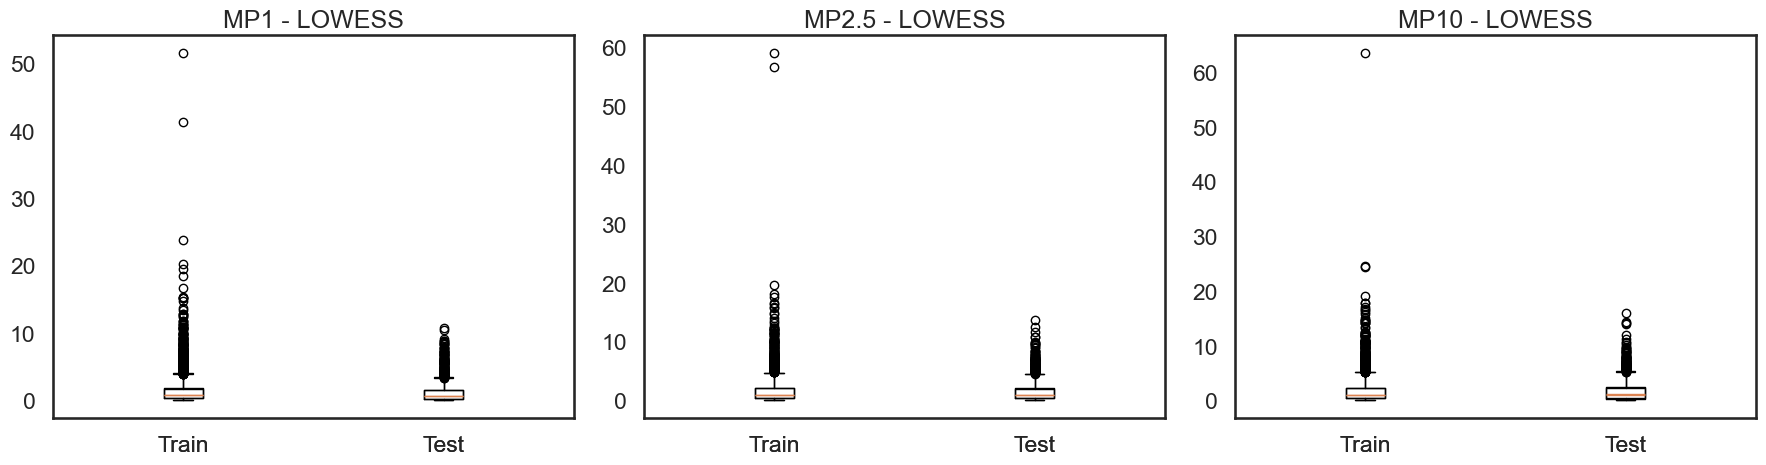

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))

for j, frac in enumerate(["MP1","MP2.5","MP10"]):

    ax = axs[j]

    for modelo, cor in zip(["MBM","LOWESS"], ["blue","orange"]):

        erros_train = []
        erros_test = []

        for casa in resultados_series.keys():

            key = (frac, modelo)
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            erro = np.abs(obs[mask] - pred[mask])

            # aproximação: metade treino / metade teste (ou use splits reais se tiver)
            split = int(len(erro)*0.7)

            erros_train.extend(erro[:split])
            erros_test.extend(erro[split:])

        ax.boxplot([erros_train, erros_test],
                   labels=["Train","Test"])

        ax.set_title(f"{frac} - {modelo}")

plt.tight_layout()
plt.show()

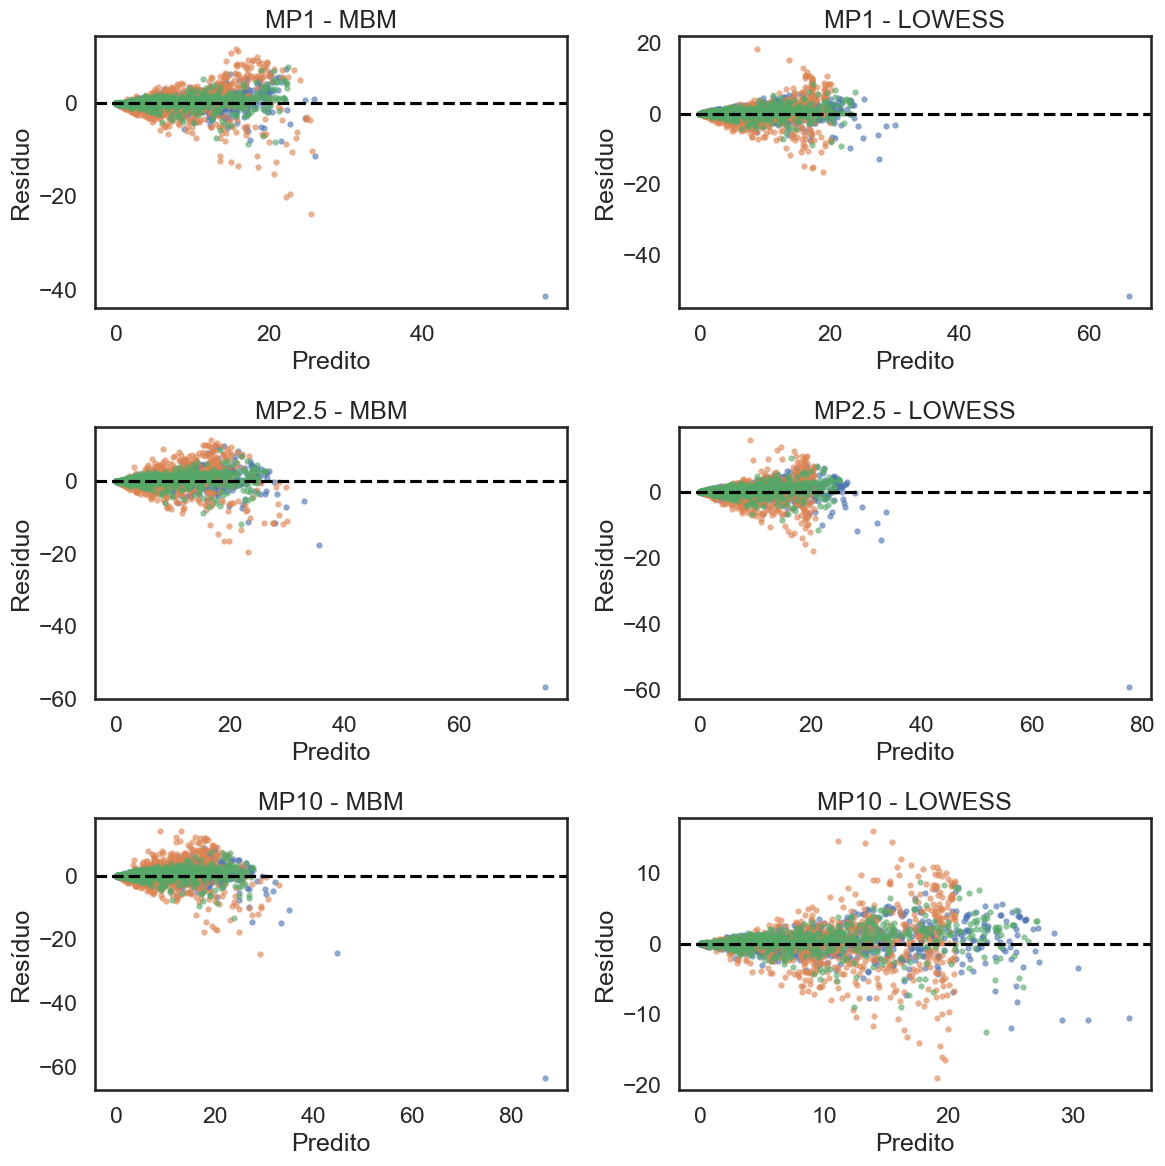

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(12,12))

for i, frac in enumerate(["MP1","MP2.5","MP10"]):
    for j, modelo in enumerate(["MBM","LOWESS"]):

        ax = axs[i,j]

        for casa in resultados_series.keys():

            key = (frac, modelo)
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            res = obs[mask] - pred[mask]

            ax.scatter(pred[mask], res, alpha=0.5, s=10)

        ax.axhline(0, linestyle="--", color="black")

        ax.set_title(f"{frac} - {modelo}")
        ax.set_xlabel("Predito")
        ax.set_ylabel("Resíduo")

plt.tight_layout()
plt.show()

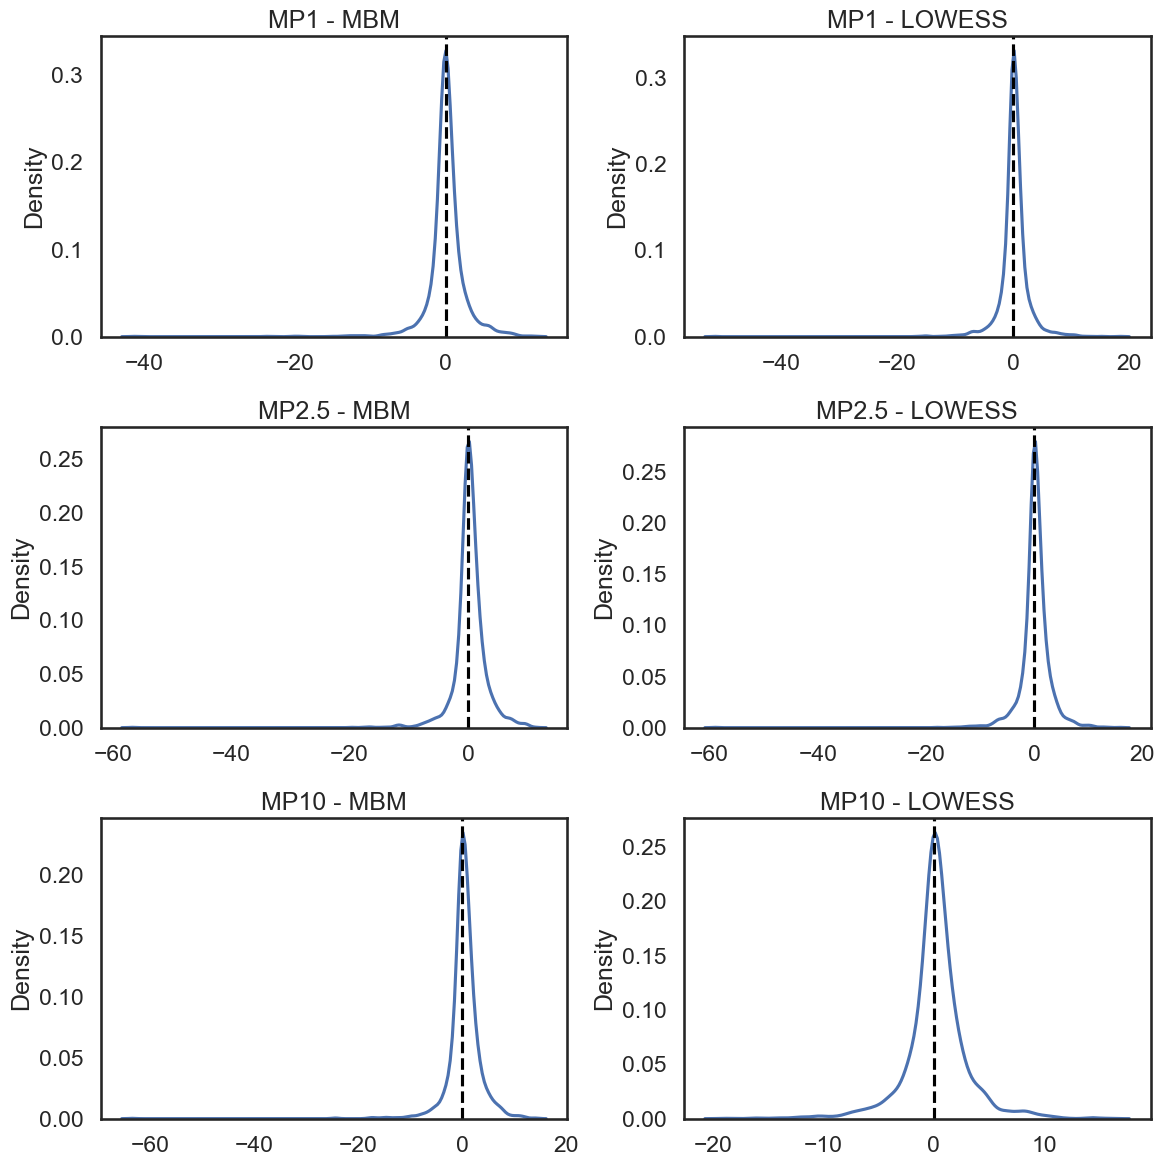

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(12,12))

for i, frac in enumerate(["MP1","MP2.5","MP10"]):
    for j, modelo in enumerate(["MBM","LOWESS"]):

        ax = axs[i,j]

        all_res = []

        for casa in resultados_series.keys():

            key = (frac, modelo)
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            all_res.extend(obs[mask] - pred[mask])

        sns.kdeplot(all_res, ax=ax)

        ax.axvline(0, linestyle="--", color="black")

        ax.set_title(f"{frac} - {modelo}")

plt.tight_layout()
plt.show()

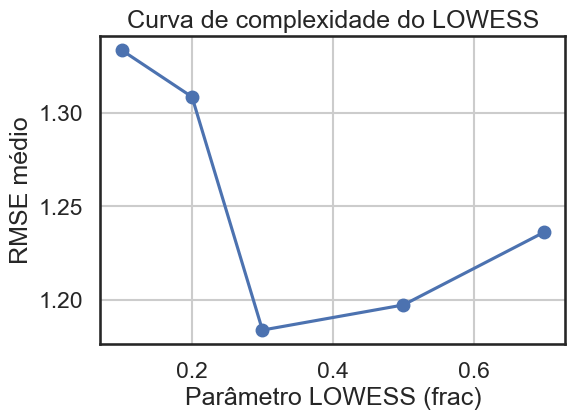

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

fracs = [0.1, 0.2, 0.3, 0.5, 0.7]

resultados_complexidade = {}

for frac_val in fracs:

    rmse_total = []

    for casa in resultados_series.keys():
        for frac in ["MP1","MP2.5","MP10"]:

            key = (frac, "LOWESS")
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            Cin = dados["Cin_obs"]
            Cout = dados["Cin_obs"] / dados["Finf_vals"][:len(dados["Cin_obs"])]

            mask = np.isfinite(Cin) & np.isfinite(Cout) & (Cout > 0)

            Cin = Cin[mask]
            Cout = Cout[mask]

            if len(Cin) < 30:
                continue

            tscv = TimeSeriesSplit(n_splits=5)

            for train_idx, test_idx in tscv.split(Cout):

                Cin_train, Cin_test = Cin[train_idx], Cin[test_idx]
                Cout_train, Cout_test = Cout[train_idx], Cout[test_idx]

                ratio = Cin_train / Cout_train
                ratio = np.clip(ratio, 1e-6, 1-1e-6)

                # LOWESS treino
                lowess_fit = sm.nonparametric.lowess(
                    endog=ratio,
                    exog=Cout_train,
                    frac=frac_val,
                    return_sorted=True
                )

                x_low = lowess_fit[:,0]
                y_low = lowess_fit[:,1]

                if len(x_low) < 2:
                    continue

                f_interp = interp1d(
                    x_low,
                    y_low,
                    bounds_error=False,
                    fill_value="extrapolate"
                )

                Finf_pred = f_interp(Cout_test)
                Finf_pred = np.clip(Finf_pred, 1e-6, 1-1e-6)

                Cin_pred = Finf_pred * Cout_test

                rmse = np.sqrt(mean_squared_error(Cin_test, Cin_pred))
                rmse_total.append(rmse)

    resultados_complexidade[frac_val] = np.mean(rmse_total)

# =========================
# PLOT
# =========================
fracs_plot = list(resultados_complexidade.keys())
rmse_plot = list(resultados_complexidade.values())

plt.figure(figsize=(6,4))
plt.plot(fracs_plot, rmse_plot, marker='o')
plt.xlabel("Parâmetro LOWESS (frac)")
plt.ylabel("RMSE médio")
plt.title("Curva de complexidade do LOWESS")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

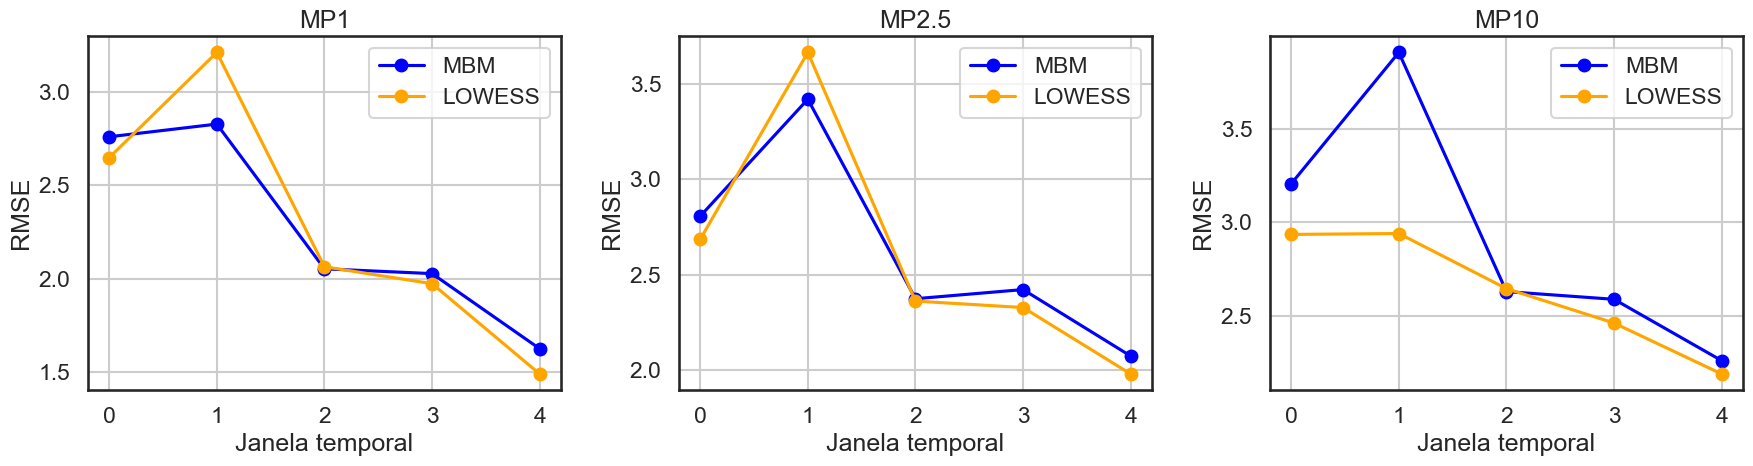

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))

for j, frac in enumerate(["MP1","MP2.5","MP10"]):

    ax = axs[j]

    for modelo, cor in zip(["MBM","LOWESS"], ["blue","orange"]):

        erros_fold = []

        for casa in resultados_series.keys():

            key = (frac, modelo)
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            erro = np.abs(obs[mask] - pred[mask])

            # dividir progressivamente (simula TimeSeriesSplit)
            splits = np.array_split(erro, 5)

            rmse_fold = [np.sqrt(np.mean(s**2)) for s in splits if len(s) > 5]

            if len(rmse_fold) > 0:
                erros_fold.append(rmse_fold)

        if len(erros_fold) > 0:
            erros_fold = np.mean(erros_fold, axis=0)
            ax.plot(erros_fold, marker='o', color=cor, label=modelo)

    ax.set_title(frac)
    ax.set_xlabel("Janela temporal")
    ax.set_ylabel("RMSE")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

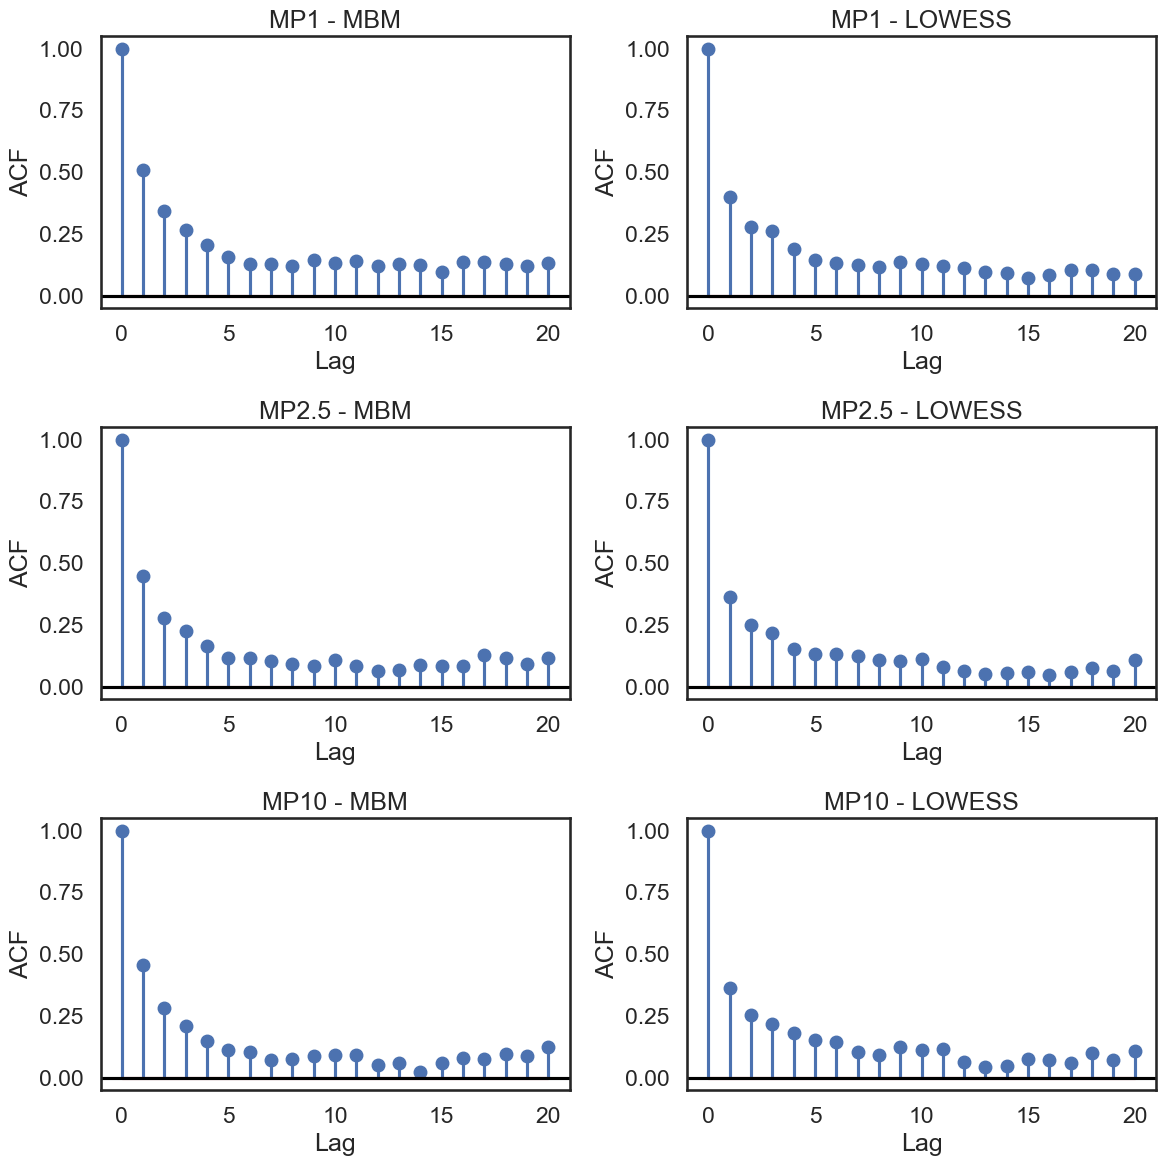

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(12,12))

for i, frac in enumerate(["MP1","MP2.5","MP10"]):
    for j, modelo in enumerate(["MBM","LOWESS"]):

        ax = axs[i,j]

        all_res = []

        for casa in resultados_series.keys():

            key = (frac, modelo)
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            res = obs[mask] - pred[mask]
            all_res.extend(res)

        if len(all_res) > 20:
            acf_vals = acf(all_res, nlags=20)

            ax.stem(acf_vals)
            ax.axhline(0, color='black')

        ax.set_title(f"{frac} - {modelo}")
        ax.set_xlabel("Lag")
        ax.set_ylabel("ACF")

plt.tight_layout()
plt.show()

In [ ]:
print("\n===== TESTE DE LJUNG-BOX =====")

for frac in ["MP1","MP2.5","MP10"]:
    for modelo in ["MBM","LOWESS"]:

        all_res = []

        for casa in resultados_series.keys():

            key = (frac, modelo)
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            res = obs[mask] - pred[mask]
            all_res.extend(res)

        if len(all_res) > 20:

            lb = acorr_ljungbox(all_res, lags=[10], return_df=True)

            p_val = lb["lb_pvalue"].values[0]

            print(f"{frac} - {modelo}: p = {p_val:.4f}")

            if p_val > 0.05:
                print("  ✅ resíduos independentes")
            else:
                print("  ⚠️ autocorrelação presente")


===== TESTE DE LJUNG-BOX =====
MP1 - MBM: p = 0.0000
  ⚠️ autocorrelação presente
MP1 - LOWESS: p = 0.0000
  ⚠️ autocorrelação presente
MP2.5 - MBM: p = 0.0000
  ⚠️ autocorrelação presente
MP2.5 - LOWESS: p = 0.0000
  ⚠️ autocorrelação presente
MP10 - MBM: p = 0.0000
  ⚠️ autocorrelação presente
MP10 - LOWESS: p = 0.0000
  ⚠️ autocorrelação presente


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from scipy.interpolate import interp1d
import numpy as np

def otimizar_lowess(Cin, Cout, fracs=np.linspace(0.1,0.7,7), n_splits=5):

    tscv = TimeSeriesSplit(n_splits=n_splits)

    resultados = []

    for frac_val in fracs:

        rmse_folds = []

        for train_idx, test_idx in tscv.split(Cout):

            Cin_train, Cin_test = Cin[train_idx], Cin[test_idx]
            Cout_train, Cout_test = Cout[train_idx], Cout[test_idx]

            ratio = Cin_train / Cout_train
            ratio = np.clip(ratio, 1e-6, 1-1e-6)

            lowess_fit = sm.nonparametric.lowess(
                endog=ratio,
                exog=Cout_train,
                frac=frac_val,
                return_sorted=True
            )

            x_low = lowess_fit[:,0]
            y_low = lowess_fit[:,1]

            if len(x_low) < 2:
                continue

            f_interp = interp1d(
                x_low,
                y_low,
                bounds_error=False,
                fill_value="extrapolate"
            )

            Finf_pred = f_interp(Cout_test)
            Finf_pred = np.clip(Finf_pred, 1e-6, 1-1e-6)

            Cin_pred = Finf_pred * Cout_test

            rmse = np.sqrt(mean_squared_error(Cin_test, Cin_pred))
            rmse_folds.append(rmse)

        if len(rmse_folds) > 0:
            resultados.append((frac_val, np.mean(rmse_folds)))

    # melhor frac
    melhor_frac = min(resultados, key=lambda x: x[1])[0]

    return melhor_frac, resultados

In [ ]:
melhores_fracs = {}

for arquivo in ARQUIVOS:
    casa = CASAS[arquivo]
    melhores_fracs[casa] = {}

    for frac_label, (col_cin, col_cout) in FRACOES.items():

        Cin, Cout = preparar_dados(arquivo, col_cin, col_cout)

        if len(Cin) < 30:
            continue

        frac_opt, curva = otimizar_lowess(Cin, Cout)

        melhores_fracs[casa][frac_label] = frac_opt

        print(f"{casa} - {frac_label}: frac ótimo = {frac_opt:.2f}")

R5 - MP1: frac ótimo = 0.10
R5 - MP2.5: frac ótimo = 0.10
R5 - MP10: frac ótimo = 0.50
R6 - MP1: frac ótimo = 0.50


c:\Users\melin\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


ValueError: Input contains NaN.

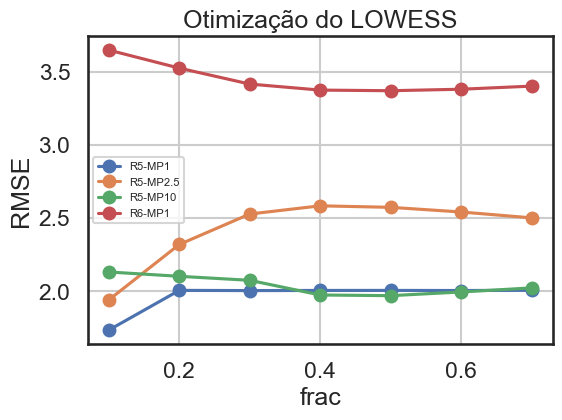

In [ ]:
plt.figure(figsize=(6,4))

for casa in melhores_fracs:
    for frac in melhores_fracs[casa]:

        Cin, Cout = preparar_dados(
            [k for k,v in CASAS.items() if v==casa][0],
            FRACOES[frac][0],
            FRACOES[frac][1]
        )

        frac_opt, curva = otimizar_lowess(Cin, Cout)

        fracs = [x[0] for x in curva]
        rmses = [x[1] for x in curva]

        plt.plot(fracs, rmses, marker='o', label=f"{casa}-{frac}")

plt.xlabel("frac")
plt.ylabel("RMSE")
plt.title("Otimização do LOWESS")
plt.legend(fontsize=8)
plt.grid()
plt.show()

In [ ]:
# =========================
# COMPARAÇÃO ANTES vs DEPOIS
# =========================

df_before = df_resultados.copy()
df_after = df_resultados_opt.copy()

df_before["Tipo"] = "Antes"
df_after["Tipo"] = "Depois"

df_comp = pd.concat([df_before, df_after])

metricas = ["RMSE", "R²", "NMSE", "FB"]

for metrica in metricas:

    plt.figure(figsize=(10,5))

    for modelo, cor in zip(["MBM","LOWESS"], ["blue","orange"]):

        df_plot = df_comp[df_comp["Modelo"] == modelo]

        for tipo, estilo in zip(["Antes","Depois"], ["--","-"]):

            df_tipo = df_plot[df_plot["Tipo"] == tipo]

            plt.plot(df_tipo[metrica].values,
                     linestyle=estilo,
                     marker='o',
                     label=f"{modelo}-{tipo}",
                     color=cor)

    plt.title(f"Comparação {metrica}: Antes vs Depois")
    plt.xlabel("Casos (Casa × Fração)")
    plt.ylabel(metrica)
    plt.legend()
    plt.grid(True)
    plt.show()

NameError: name 'df_resultados_opt' is not defined

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))

for j, frac in enumerate(["MP1","MP2.5","MP10"]):

    ax = axs[j]

    for casa in resultados_series_otimizados:

        for modelo, cor in zip(["MBM","LOWESS"], ["blue","orange"]):

            key = (frac, modelo)
            if key not in resultados_series_otimizados[casa]:
                continue

            dados = resultados_series_otimizados[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            ax.scatter(obs[mask], pred[mask],
                       color=cor, alpha=0.6, s=15,
                       label=modelo if casa == "R1" else None)

    lims = ax.get_xlim()
    ax.plot(lims, lims, 'k--')

    ax.set_title(frac)
    ax.set_xlabel("Observado")
    ax.set_ylabel("Modelado")
    ax.grid(True)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
import optuna.visualization.matplotlib as optuna_vis

for casa in estudos_optuna:
    for frac in estudos_optuna[casa]:

        for modelo in ["LOWESS","MBM"]:

            study = estudos_optuna[casa][frac][modelo]

            print(f"\n{casa} - {frac} - {modelo}")

            # Histórico de otimização
            fig = optuna_vis.plot_optimization_history(study)
            plt.title(f"Histórico: {casa}-{frac}-{modelo}")
            plt.show()

            # Importância dos parâmetros
            fig = optuna_vis.plot_param_importances(study)
            plt.title(f"Importância: {casa}-{frac}-{modelo}")
            plt.show()

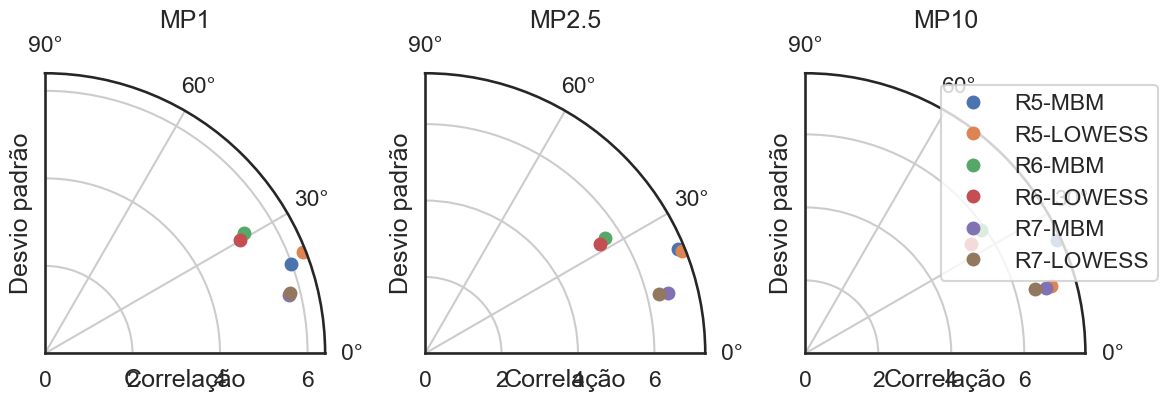

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def taylor_diagram(ax, ref_std, samples, labels):

    for i, (std, corr, label) in enumerate(zip(samples["std"], samples["corr"], labels)):
        theta = np.arccos(corr)
        ax.plot(theta, std, 'o', label=label)

    ax.set_thetamin(0)
    ax.set_thetamax(90)

    ax.set_xlabel("Correlação")
    ax.set_ylabel("Desvio padrão")

    ax.grid(True)


fig = plt.figure(figsize=(12, 5))
axs = [fig.add_subplot(1,3,i+1, projection='polar') for i in range(3)]

for j, frac in enumerate(["MP1","MP2.5","MP10"]):

    stds = []
    corrs = []
    labels = []

    for casa in ["R5","R6","R7"]:  #"R1","R2","R3","R4"
        for modelo in ["MBM","LOWESS"]:

            key = (frac, modelo)
            if key not in resultados_series[casa]:
                continue

            dados = resultados_series[casa][key]

            obs = dados["Cin_obs"]
            pred = dados["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred)

            obs = obs[mask]
            pred = pred[mask]

            stds.append(np.std(pred))
            corrs.append(np.corrcoef(obs, pred)[0,1])
            labels.append(f"{casa}-{modelo}")

    taylor_diagram(axs[j], np.std(obs), {"std": stds, "corr": corrs}, labels)

    axs[j].set_title(frac)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

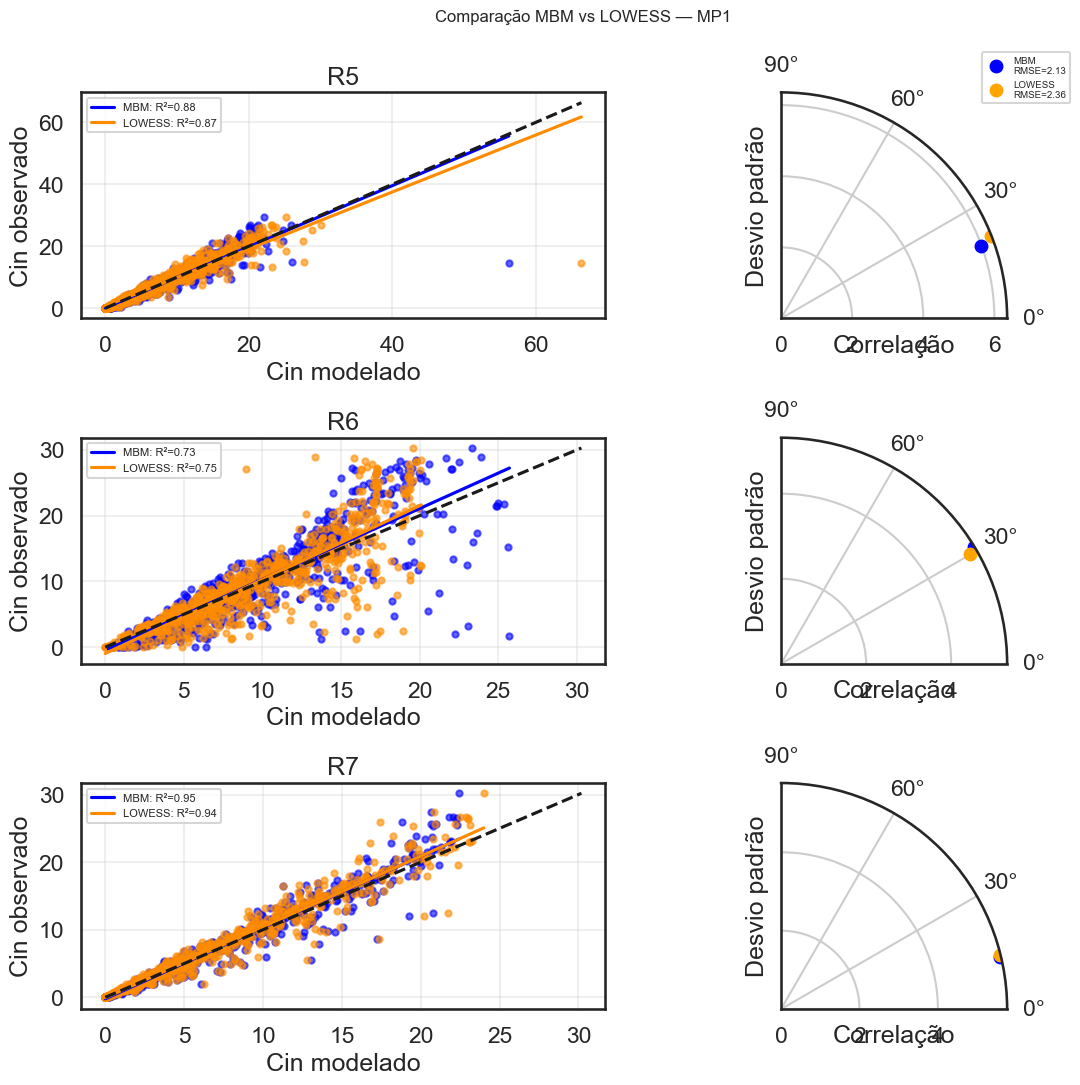

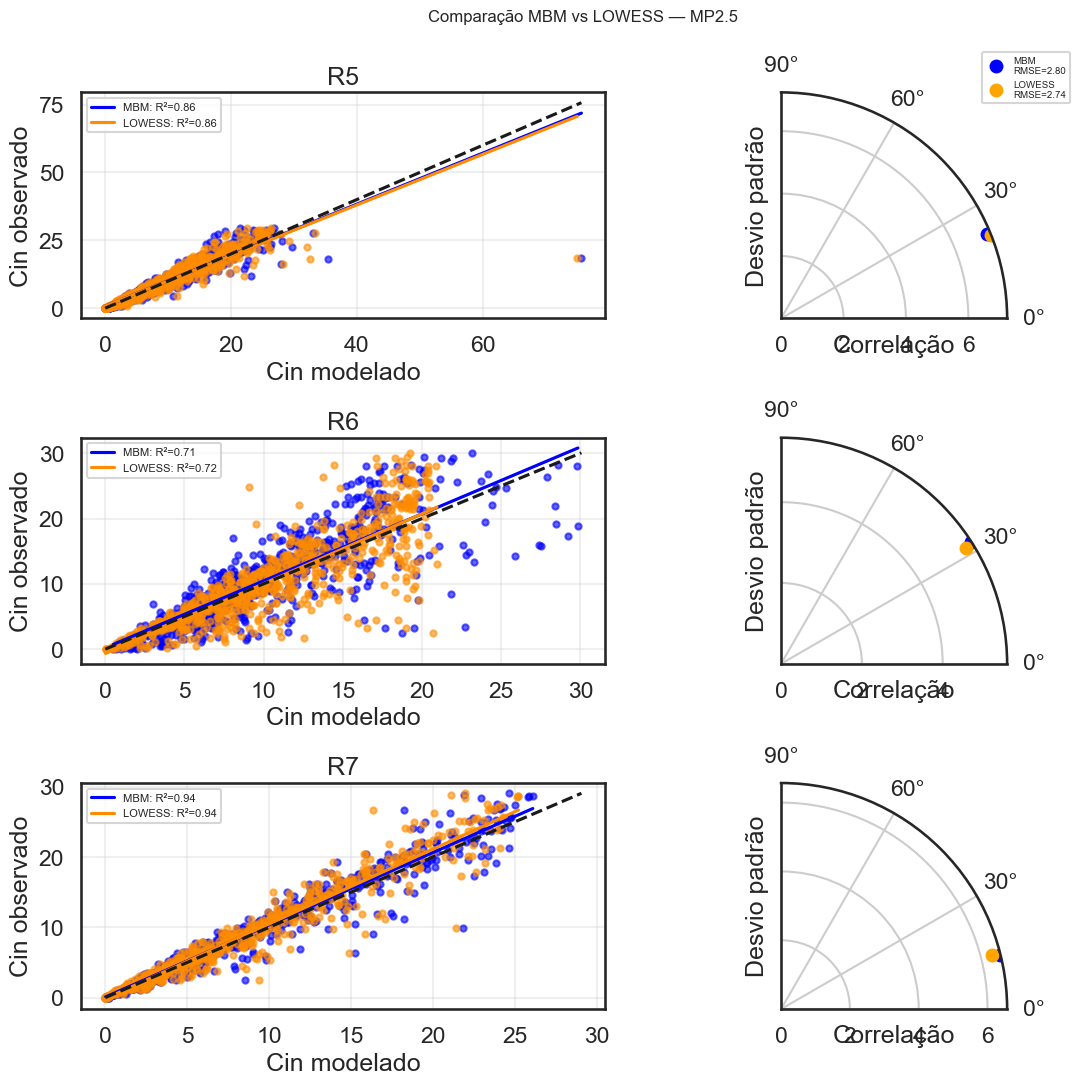

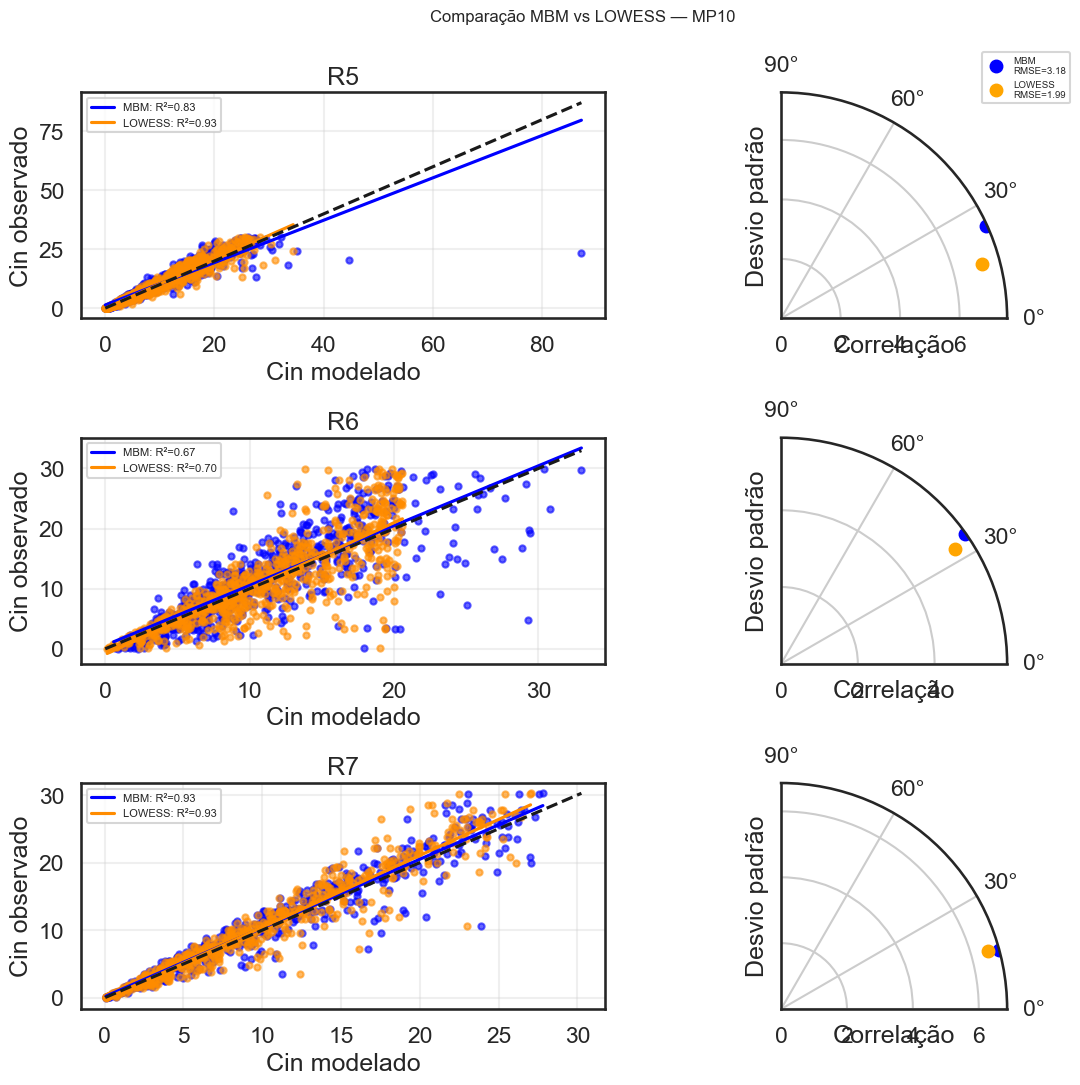

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


for frac in ["MP1","MP2.5","MP10"]:

    fig = plt.figure(figsize=(12, 14))
    fig.suptitle(f"Comparação MBM vs LOWESS — {frac}", fontsize=12)

    for i, casa in enumerate(["R5","R6","R7"]):

        # =========================
        # CRIAR SUBPLOTS MANUALMENTE
        # =========================
        ax_reg = fig.add_subplot(4, 2, 2*i + 1)
        ax_tay = fig.add_subplot(4, 2, 2*i + 2, projection='polar')

        key_mbm = (frac, "MBM")
        key_low = (frac, "LOWESS")

        if key_mbm not in resultados_series[casa] or key_low not in resultados_series[casa]:
            ax_reg.axis("off")
            ax_tay.axis("off")
            continue

        dados_mbm = resultados_series[casa][key_mbm]
        dados_low = resultados_series[casa][key_low]

        obs = dados_mbm["Cin_obs"]
        pred_mbm = dados_mbm["Cin_pred"]
        pred_low = dados_low["Cin_pred"]

        mask = np.isfinite(obs) & np.isfinite(pred_mbm) & np.isfinite(pred_low)

        obs = obs[mask]
        pred_mbm = pred_mbm[mask]
        pred_low = pred_low[mask]

        # =========================
        # REGRESSÃO
        # =========================
        for pred, cor, label in zip([pred_mbm, pred_low],
                                   ["blue","darkorange"],
                                   ["MBM","LOWESS"]):

            slope, intercept, r, p, _ = linregress(pred, obs)

            x = np.linspace(min(pred), max(pred), 100)
            y = slope*x + intercept

            ax_reg.scatter(pred, obs, color=cor, alpha=0.6, s=20)
            ax_reg.plot(x, y, color=cor,
                        label=f"{label}: R²={r**2:.2f}")

        lim = [min(obs.min(), pred_mbm.min(), pred_low.min()),
               max(obs.max(), pred_mbm.max(), pred_low.max())]

        ax_reg.plot(lim, lim, 'k--')

        ax_reg.set_title(f"{casa}")
        ax_reg.set_xlabel("Cin modelado")
        ax_reg.set_ylabel("Cin observado")
        ax_reg.legend(fontsize=8)
        ax_reg.grid(True, alpha=0.3)

        # =========================
        # TAYLOR DIAGRAM
        # =========================
        def plot_point(pred, label, color):

            std = np.std(pred)
            corr = np.corrcoef(obs, pred)[0,1]
            rmse = np.sqrt(np.mean((obs - pred)**2))

            theta = np.arccos(np.clip(corr, -1, 1))
            ax_tay.plot(theta, std, 'o', color=color,
                        label=f"{label}\nRMSE={rmse:.2f}")

        plot_point(pred_mbm, "MBM", "blue")
        plot_point(pred_low, "LOWESS", "orange")

        ax_tay.set_thetamin(0)
        ax_tay.set_thetamax(90)
        ax_tay.set_xlabel("Correlação")
        ax_tay.set_ylabel("Desvio padrão")
        #ax_tay.set_title("Taylor", fontsize=10)
        ax_tay.grid(True)

        if i == 0:
            ax_tay.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.3,1.2))

    plt.tight_layout(rect=[0,0,1,1])
    plt.show()

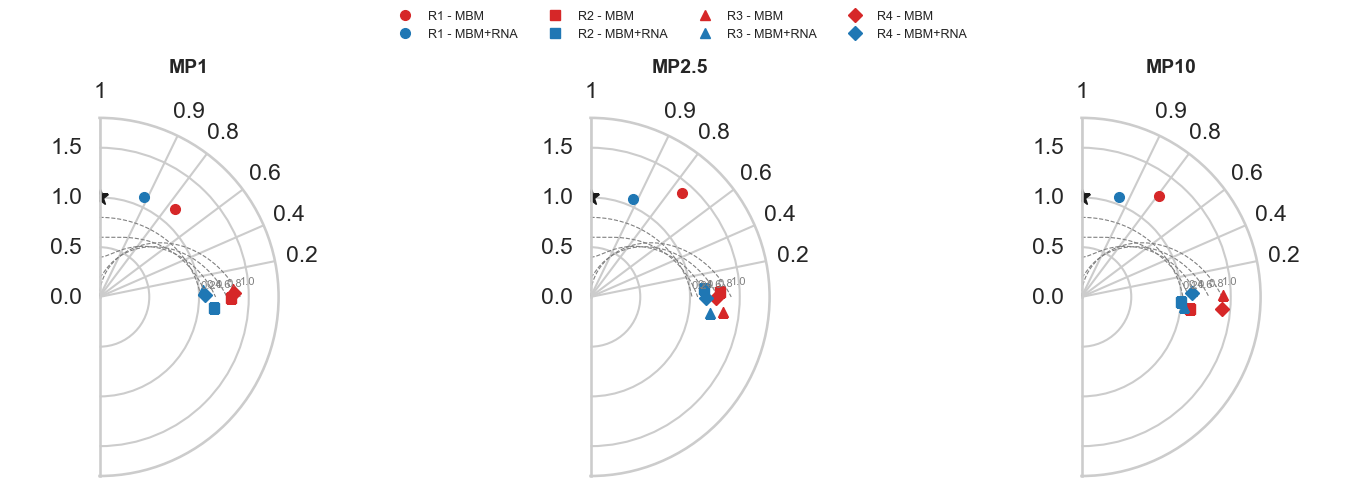

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# FUNÇÃO TAYLOR (versão publicação)
# =========================
def taylor_diagram(ax, ref, modelos_mbm, modelos_hibrido, casas):

    ref = np.array(ref)
    ref_std = np.std(ref, ddof=1)

    # limites
    r_max = 1.8

    # ======================
    # RMSE (arcos)
    # ======================
    thetas = np.linspace(0, np.pi/2, 200)

    for rmse in [0.2, 0.4, 0.6, 0.8, 1.0]:
        r = np.sqrt(1 + rmse**2 - 2*rmse*np.cos(thetas))
        ax.plot(thetas, r, color='gray', linestyle='--', linewidth=0.8)
        ax.text(np.radians(85), r[-1], f"{rmse:.1f}", fontsize=8, color='gray')

    # ======================
    # marcadores por casa
    # ======================
    markers = ['o', 's', '^', 'D']

    # ======================
    # plot MBM e Híbrido
    # ======================
    for i, casa in enumerate(casas):

        for modelo, cor, label_base in zip(
            [modelos_mbm[casa], modelos_hibrido[casa]],
            ['#d62728', '#1f77b4'],  # vermelho / azul
            ['MBM', 'MBM+RNA']
        ):

            model = np.array(modelo)

            mask = ~np.isnan(ref) & ~np.isnan(model)
            ref_v = ref[mask]
            mod_v = model[mask]

            std = np.std(mod_v, ddof=1)
            corr = np.corrcoef(ref_v, mod_v)[0,1]

            theta = np.arccos(corr)
            r = std / ref_std

            ax.plot(theta, r,
                    marker=markers[i],
                    color=cor,
                    markersize=7,
                    linestyle='None',
                    label=f"{casa} - {label_base}")

    # ======================
    # referência
    # ======================
    ax.plot(0, 1, 'k*', markersize=12)

    # ======================
    # configuração
    # ======================
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    ax.set_thetamin(0)
    ax.set_thetamax(180)

    corr_ticks = [0.2,0.4,0.6,0.8,0.9,1]
    ax.set_thetagrids(np.degrees(np.arccos(corr_ticks)),
                      labels=[str(c) for c in corr_ticks])

    ax.set_rlabel_position(135)
    ax.set_ylim(0, r_max)

    ax.grid(True)


# =========================
# EXEMPLO (SUBSTITUA PELOS SEUS DADOS)
# =========================

np.random.seed(42)

fracoes = ["MP1", "MP2.5", "MP10"]
casas = ["R5", "R6", "R7"]

dados = {}

for fr in fracoes:
    dados[fr] = {}
    for casa in casas:

        ref = np.random.rand(100)

        dados[fr][casa] = {
            "ref": ref,
            "MBM": ref + np.random.normal(0, 0.25, 100),
            "HIBRIDO": ref + np.random.normal(0, 0.12, 100)
        }

# =========================
# FIGURA FINAL
# =========================

fig, axs = plt.subplots(1, 3, figsize=(15,5),
                        subplot_kw=dict(projection='polar'))

for i, fr in enumerate(fracoes):

    ax = axs[i]

    ref = dados[fr][casas[0]]["ref"]

    modelos_mbm = {c: dados[fr][c]["MBM"] for c in casas}
    modelos_hibrido = {c: dados[fr][c]["HIBRIDO"] for c in casas}

    taylor_diagram(ax, ref, modelos_mbm, modelos_hibrido, casas)

    ax.set_title(fr, fontsize=14, fontweight='bold')

# =========================
# legenda organizada
# =========================

handles, labels = axs[0].get_legend_handles_labels()

# remover duplicados mantendo ordem
unique = dict(zip(labels, handles))

fig.legend(unique.values(), unique.keys(),
           loc='upper center',
           ncol=4,
           fontsize=9)

plt.tight_layout(rect=[0,0,1,0.90])
plt.show()

In [ ]:
from scipy.stats import kruskal, wilcoxon
import itertools

print("\n===== TESTE A (pares de frações) =====")

pares = [("MP1","MP2.5"), ("MP1","MP10"), ("MP2.5","MP10")]

for casa in resultados_series.keys():
    for modelo in ["MBM", "LOWESS"]:

        print(f"\nCasa {casa} | Modelo {modelo}")

        for f1, f2 in pares:

            key1 = (f1, modelo)
            key2 = (f2, modelo)

            if key1 in resultados_series[casa] and key2 in resultados_series[casa]:

                v1 = resultados_series[casa][key1]["Finf_vals"]
                v2 = resultados_series[casa][key2]["Finf_vals"]

                n = min(len(v1), len(v2))
                diff = v1[:n] - v2[:n]

                ic_low = np.percentile(diff, 2.5)
                ic_high = np.percentile(diff, 97.5)

                print(f"{f1} vs {f2}: IC95% = [{ic_low:.4f}, {ic_high:.4f}]")

                if ic_low > 0 or ic_high < 0:
                    print("  ✅ diferença significativa")
                else:
                    print("  ❌ sem diferença significativa")
            
            
print("\n===== TESTE B (bootstrap): diferença de Finf =====")

for casa in resultados_series.keys():
    for frac in ["MP1", "MP2.5", "MP10"]:

        key_mbm = (frac, "MBM")
        key_low = (frac, "LOWESS")

        if key_mbm in resultados_series[casa] and key_low in resultados_series[casa]:

            f1 = resultados_series[casa][key_mbm]["Finf_vals"]
            f2 = resultados_series[casa][key_low]["Finf_vals"]

            n = min(len(f1), len(f2))
            diff = f1[:n] - f2[:n]

            ic_low = np.percentile(diff, 2.5)
            ic_high = np.percentile(diff, 97.5)

            print(f"{casa}-{frac}: IC95% = [{ic_low:.4f}, {ic_high:.4f}]")

            if ic_low > 0 or ic_high < 0:
                print("  ✅ diferença significativa")
            else:
                print("  ❌ sem diferença significativa")

print("\n===== TESTE C: Desempenho (erro absoluto) =====")

for casa in resultados_series.keys():
    for frac in ["MP1", "MP2.5", "MP10"]:

        key_mbm = (frac, "MBM")
        key_low = (frac, "LOWESS")

        if key_mbm in resultados_series[casa] and key_low in resultados_series[casa]:

            obs = resultados_series[casa][key_mbm]["Cin_obs"]

            pred_mbm = resultados_series[casa][key_mbm]["Cin_pred"]
            pred_low = resultados_series[casa][key_low]["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred_mbm) & np.isfinite(pred_low)

            if np.sum(mask) > 10:
                err_mbm = np.abs(obs[mask] - pred_mbm[mask])
                err_low = np.abs(obs[mask] - pred_low[mask])

                stat, p = wilcoxon(err_mbm, err_low)

                print(f"{casa} - {frac}: p = {p:.4f}")

                if p < 0.05:
                    print("  ✅ Diferença significativa no desempenho")
                else:
                    print("  ❌ Sem diferença significativa")                                


===== TESTE A (pares de frações) =====

Casa R5 | Modelo MBM
MP1 vs MP2.5: IC95% = [-0.0413, 0.1028]
  ❌ sem diferença significativa
MP1 vs MP10: IC95% = [-0.0252, 0.1363]
  ❌ sem diferença significativa
MP2.5 vs MP10: IC95% = [-0.0545, 0.1069]
  ❌ sem diferença significativa

Casa R5 | Modelo LOWESS
MP1 vs MP2.5: IC95% = [-0.4763, 0.2372]
  ❌ sem diferença significativa
MP1 vs MP10: IC95% = [-0.4850, 0.1734]
  ❌ sem diferença significativa
MP2.5 vs MP10: IC95% = [-0.2461, 0.1729]
  ❌ sem diferença significativa

Casa R6 | Modelo MBM
MP1 vs MP2.5: IC95% = [-0.0280, 0.1829]
  ❌ sem diferença significativa
MP1 vs MP10: IC95% = [0.0383, 0.2495]
  ✅ diferença significativa
MP2.5 vs MP10: IC95% = [-0.0214, 0.1578]
  ❌ sem diferença significativa

Casa R6 | Modelo LOWESS
MP1 vs MP2.5: IC95% = [-0.2568, 0.3518]
  ❌ sem diferença significativa
MP1 vs MP10: IC95% = [-0.1820, 0.4211]
  ❌ sem diferença significativa
MP2.5 vs MP10: IC95% = [-0.2476, 0.3938]
  ❌ sem diferença significativa

Casa R

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import t

print("\n===== TESTE C: Desempenho (erro absoluto) =====")

for casa in resultados_series.keys():
    for frac in ["MP1", "MP2.5", "MP10"]:

        key_mbm = (frac, "MBM")
        key_low = (frac, "LOWESS")

        if key_mbm in resultados_series[casa] and key_low in resultados_series[casa]:

            obs = resultados_series[casa][key_mbm]["Cin_obs"]

            pred_mbm = resultados_series[casa][key_mbm]["Cin_pred"]
            pred_low = resultados_series[casa][key_low]["Cin_pred"]

            mask = np.isfinite(obs) & np.isfinite(pred_mbm) & np.isfinite(pred_low)

            if np.sum(mask) > 10:
                err_mbm = np.abs(obs[mask] - pred_mbm[mask])
                err_low = np.abs(obs[mask] - pred_low[mask])
                
                def diebold_mariano(e1, e2, h=1):
                    d = e1**2 - e2**2
                    mean_d = np.mean(d)

                    # variância robusta
                    gamma = [np.cov(d[:-lag], d[lag:])[0,1] for lag in range(1, h)]
                    var_d = np.var(d) + 2*np.sum(gamma)

                    DM_stat = mean_d / np.sqrt(var_d/len(d))
                    p_value = 2*(1 - t.cdf(np.abs(DM_stat), df=len(d)-1))

                    return DM_stat, p_value

                stat, p = diebold_mariano(err_mbm, err_low)

                print(f"{casa} - {frac}: p = {p:.4f}")

                if p < 0.05:
                    print("  ✅ Diferença significativa no desempenho")
                else:
                    print("  ❌ Sem diferença significativa")




===== TESTE C: Desempenho (erro absoluto) =====
R5 - MP1: p = 0.3548
  ❌ Sem diferença significativa
R5 - MP2.5: p = 0.0658
  ❌ Sem diferença significativa
R5 - MP10: p = 0.2091
  ❌ Sem diferença significativa
R6 - MP1: p = 0.6758
  ❌ Sem diferença significativa
R6 - MP2.5: p = 0.4954
  ❌ Sem diferença significativa
R6 - MP10: p = 0.3051
  ❌ Sem diferença significativa
R7 - MP1: p = 0.0172
  ✅ Diferença significativa no desempenho
R7 - MP2.5: p = 0.0012
  ✅ Diferença significativa no desempenho
R7 - MP10: p = 0.0143
  ✅ Diferença significativa no desempenho


            Componente Interna (µg/m³)                                \
                                 count      mean       std       min   
Casa Modelo                                                            
R1   LOWESS                       52.0 -0.006184  0.326737 -0.903256   
     MBM                          52.0  0.023721  0.304888 -0.542903   
R2   LOWESS                       64.0 -0.043871  0.395404 -1.519328   
     MBM                          64.0 -0.015391  0.241932 -0.583287   
R3   LOWESS                       89.0 -0.024517  0.455081 -1.974729   
     MBM                          89.0  0.004001  0.323718 -0.665405   
R4   LOWESS                       83.0  0.001946  0.280225 -0.658278   
     MBM                          83.0 -0.001156  0.259273 -0.877659   

                                                     
                  25%       50%       75%       max  
Casa Modelo                                          
R1   LOWESS -0.153753 -0.023747  0.171703  0.

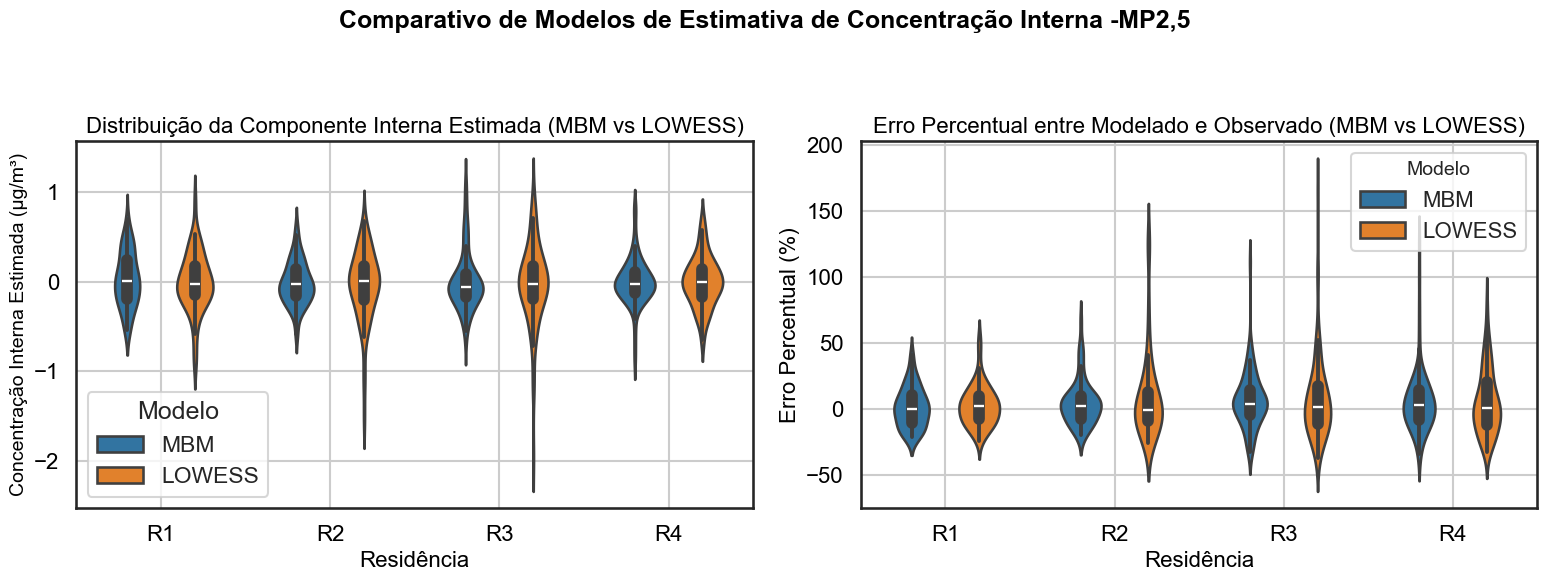

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

# --- Funções auxiliares ---
def substituir_outliers_media_local(x, window=3):
    x_corrigido = x.copy()
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    for i in range(len(x)):
        if x[i] < lim_inf or x[i] > lim_sup:
            inicio = max(0, i - window)
            fim = min(len(x), i + window + 1)
            vizinhos = x[inicio:fim]
            vizinhos = vizinhos[(vizinhos >= lim_inf) & (vizinhos <= lim_sup)]
            if len(vizinhos) > 0:
                x_corrigido[i] = np.mean(vizinhos)
    return x_corrigido

def classificar_origem(Cin, Cout, Cin_lag, Cout_lag, ratio_th=1.2, diff_in=3, diff_ext=2):
    eps = 1e-6
    if (Cin / (Cout + eps)) > ratio_th and (Cin - Cin_lag) > diff_in and (Cout - Cout_lag) < diff_ext or Cin > 45 or Cin > 30.3:
        return "interno"
    elif (Cin / (Cout + eps)) < ratio_th or Cin <= Cout:
        return "externo"
    else:
        return "desconhecido"

def gerar_blocos_externos(n_total, tamanho_bloco=6):
    return [list(range(i, i + tamanho_bloco)) for i in range(n_total - tamanho_bloco + 1)]

def simular_bloco(Finf, k_prime, Cin_obs, Cout, bloco, dt=1):
    Cin_mod = np.full_like(Cin_obs, np.nan)
    Cin_mod[bloco[0]] = Cin_obs[bloco[0]]
    for t in bloco[1:]:
        Cin_mod[t] = Finf * Cout[t] + (Cin_mod[t - 1] - Finf * Cout[t]) * np.exp(-k_prime * dt)
    return Cin_mod

def bootstrap_mbb_modelo(Cin, Cout, blocos_possiveis, n_iter=500, dt=1):
    Finf_vals, k_vals, r2_vals, rmse_vals = [], [], [], []
    simulacoes = []
    n_blocos = len(Cin) // 6

    for _ in range(n_iter):
        blocos_amostrados = [blocos_possiveis[i] for i in np.random.randint(0, len(blocos_possiveis), n_blocos)]

        def erro_total(params):
            Finf, k_prime = params
            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_mod = np.where(np.isnan(simular_bloco(Finf, k_prime, Cin, Cout, bloco, dt)), 
                                   Cin_mod, 
                                   simular_bloco(Finf, k_prime, Cin, Cout, bloco, dt))
            mask = ~np.isnan(Cin_mod)
            if np.sum(mask) < 5:
                return np.inf
            return np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2))

        res = minimize(erro_total, [0.5, 0.5], bounds=[(0.01, 1.0), (0.01, 1.0)])
        if res.success:
            Finf_opt, k_opt = res.x
            Finf_vals.append(Finf_opt)
            k_vals.append(k_opt)

            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_mod = np.where(np.isnan(simular_bloco(Finf_opt, k_opt, Cin, Cout, bloco, dt)),
                                   Cin_mod,
                                   simular_bloco(Finf_opt, k_opt, Cin, Cout, bloco, dt))
            mask = ~np.isnan(Cin_mod)
            rmse_vals.append(np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2)))
            if np.sum(mask) > 5:
                r2_vals.append(r2_score(Cin[mask], Cin_mod[mask]))

            simulacoes.append(Cin_mod)

    return np.array(Finf_vals), np.array(k_vals), np.array(simulacoes), np.array(r2_vals), np.array(rmse_vals)

def lowess_with_confidence_bounds(x, y, eval_x, N=20, conf_interval=0.95, lowess_kw=None):
    smoothed = sm.nonparametric.lowess(exog=x, endog=y, xvals=eval_x, **lowess_kw)
    smoothed_values = np.empty((N, len(eval_x)))
    for i in range(N):
        sample = np.random.choice(len(x), len(x), replace=True)
        sampled_x = x[sample]
        sampled_y = y[sample]
        smoothed_values[i] = sm.nonparametric.lowess(
            exog=sampled_x, endog=sampled_y, xvals=eval_x, **lowess_kw
        )
    sorted_values = np.sort(smoothed_values, axis=0)
    bound = int(N * (1 - conf_interval) / 2)
    return smoothed, sorted_values[bound], sorted_values[-bound - 1]

# --- Loop geral ---
casas = ["casa1PM.xlsx", "casa2PM.xlsx", "casa3PM.xlsx", "casa4PM.xlsx"]
casa_labels = {f"casa{i+1}PM.xlsx": f"R{i+1}" for i in range(4)}
dados_por_casa = {}

for casa in casas:
    df = pd.read_excel(casa)
    Cin = df['cinPM1'].values
    Cout = df['coutPM1'].values
    Cout_corrigido = substituir_outliers_media_local(Cout)

    Cin_lag = np.roll(Cin, 1); Cin_lag[0] = Cin[0]
    Cout_lag = np.roll(Cout_corrigido, 1); Cout_lag[0] = Cout_corrigido[0]

    classes = [classificar_origem(Cin[i], Cout_corrigido[i], Cin_lag[i], Cout_lag[i]) for i in range(len(Cin))]
    df_filtrado = pd.DataFrame({'Cin': Cin, 'Cout': Cout_corrigido, 'Classe': classes}).reset_index(drop=True)
    df_ext = df_filtrado[df_filtrado['Classe'] == 'externo'].reset_index(drop=True)

    Cin_ext = df_ext['Cin'].values
    Cout_ext = df_ext['Cout'].values

    # --- MBM ---
    blocos = gerar_blocos_externos(len(Cin_ext))
    Finf_vals, k_vals, simulacoes, r2_vals, rmse_vals = bootstrap_mbb_modelo(Cin_ext, Cout_ext, blocos, n_iter=200)
    Cin_modelado_mean = np.nanmean(simulacoes[~np.isnan(simulacoes).all(axis=1)], axis=0)
    int_mbm = Cin_ext - (Cin_modelado_mean)
    erro_mbm = ((-Cin_ext + (Cin_modelado_mean)) / Cin_ext) * 100

    # --- LOWESS ---
    raw_ratio = Cin_ext / Cout_ext
    mask = (Cout_ext > 0) & (~np.isnan(Cin_ext)) & (~np.isnan(Cout_ext)) & (raw_ratio <= 1.2) & (raw_ratio > 0.3)
    x = Cout_ext[mask]
    y = raw_ratio[mask]
    eval_x = np.linspace(x.min(), x.max(), 200)
    smoothed, _, _ = lowess_with_confidence_bounds(x, y, eval_x, N=20, conf_interval=0.95, lowess_kw={"frac": 0.3})
    interp_func = interp1d(eval_x, smoothed, fill_value='extrapolate')
    y_pred = interp_func(Cout_ext[mask]) * Cout_ext[mask]
    int_lowess = Cin_ext[mask] - (y_pred)
    erro_lowess = ((-Cin_ext[mask] + (y_pred)) / Cin_ext[mask]) * 100

    dados_por_casa[casa] = {
        'int_mbm': int_mbm[:len(y_pred)],
        'int_lowess': int_lowess,
        'erro_mbm': erro_mbm[:len(y_pred)],
        'erro_lowess': erro_lowess
    }

# --- Plotagem comparativa ---
df_violin = []
df_resid = []

for casa, valores in dados_por_casa.items():
    nome = casa_labels[casa]
    df_violin.extend([{"Casa": nome, "Modelo": "MBM", "Componente Interna (µg/m³)": v} for v in valores['int_mbm']])
    df_violin.extend([{"Casa": nome, "Modelo": "LOWESS", "Componente Interna (µg/m³)": v} for v in valores['int_lowess']])
    df_resid.extend([{"Casa": nome, "Modelo": "MBM", "Erro (%)": v} for v in valores['erro_mbm']])
    df_resid.extend([{"Casa": nome, "Modelo": "LOWESS", "Erro (%)": v} for v in valores['erro_lowess']])

# DataFrames
violin_df = pd.DataFrame(df_violin)
resid_df = pd.DataFrame(df_resid)


estatisticas_modelo = violin_df.groupby(['Casa', 'Modelo']).describe()
print(estatisticas_modelo)
erros_modelo = resid_df.groupby(['Casa', 'Modelo']).describe()
print(erros_modelo)


custom_palette = {"MBM": "#1f77b4", "LOWESS": "#ff7f0e"}  # Azul escuro e laranja vibrante

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Violinplot - Componente Interna
sns.violinplot(
    data=violin_df, x="Casa", y="Componente Interna (µg/m³)", hue="Modelo",
    ax=axs[0], palette=custom_palette, dodge=True, gap=0.4
)
axs[0].set_title("Distribuição da Componente Interna Estimada (MBM vs LOWESS)", fontsize=16, color='black')
axs[0].set_xlabel("Residência", fontsize=16, color='black')
axs[0].set_ylabel("Concentração Interna Estimada (µg/m³)", fontsize=14, color='black')
axs[0].tick_params(axis='both', labelsize=16, colors='black')
#axs[0].legend(title='Modelo', title_fontsize=16, fontsize=11, loc='upper right')
axs[0].grid(True)

# Violinplot - Erro Percentual
sns.violinplot(
    data=resid_df, x="Casa", y="Erro (%)", hue="Modelo",
    ax=axs[1], palette=custom_palette, dodge=True, gap=0.4
)
axs[1].set_title("Erro Percentual entre Modelado e Observado (MBM vs LOWESS)", fontsize=16, color='black')
axs[1].set_xlabel("Residência", fontsize=16, color='black')
axs[1].set_ylabel("Erro Percentual (%)", fontsize=16, color='black')
axs[1].tick_params(axis='both', labelsize=16, colors='black')
axs[1].legend(title='Modelo', title_fontsize=14, fontsize=16, loc='upper right')
axs[1].grid(True)

fig.suptitle("Comparativo de Modelos de Estimativa de Concentração Interna -MP2,5", fontsize=18, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


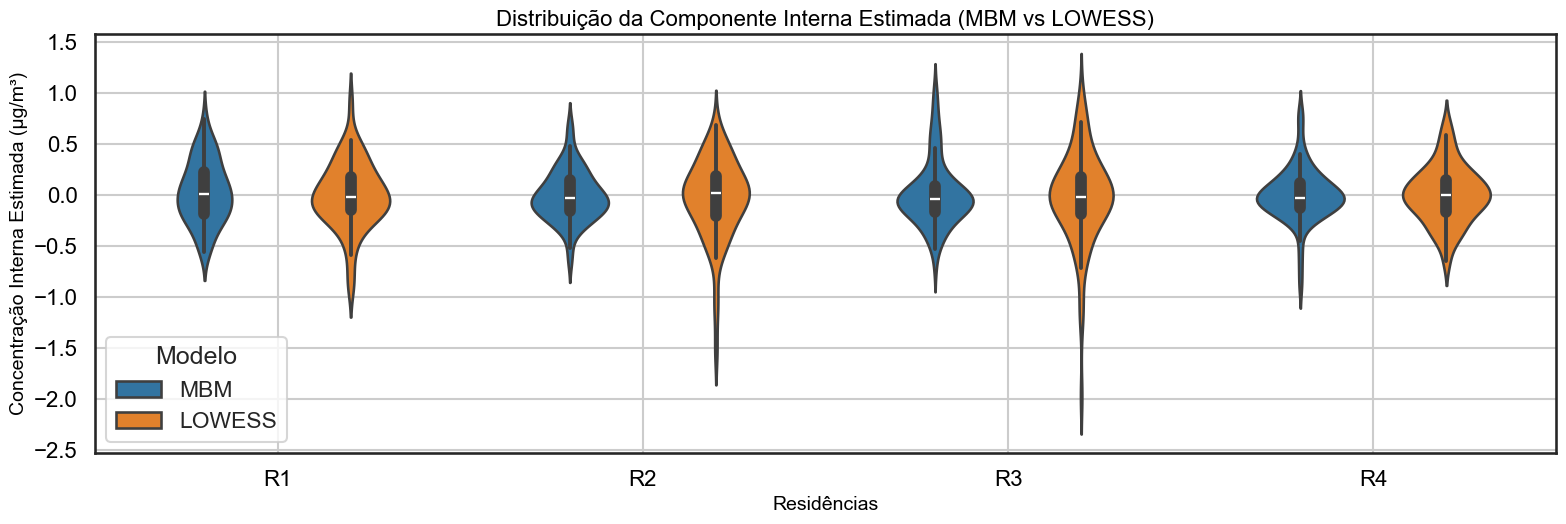

In [ ]:

plt.figure(figsize=(16, 6))
# Violinplot - Componente Interna
sns.violinplot(
    data=violin_df, x="Casa", y="Componente Interna (µg/m³)", hue="Modelo",
    palette=custom_palette, dodge=True, gap=0.4
)
plt.title("Distribuição da Componente Interna Estimada (MBM vs LOWESS)", fontsize=16, color='black')
plt.xlabel("Residências", fontsize=14, color='black')
plt.ylabel("Concentração Interna Estimada (µg/m³)", fontsize=14, color='black')
plt.tick_params(axis='both', labelsize=16, colors='black')
#axs[0].legend(title='Modelo', title_fontsize=16, fontsize=11, loc='upper right')
plt.grid(True)

#fig.suptitle("Comparativo de Modelos de Estimativa de Concentração Interna -MP2,5", fontsize=18, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



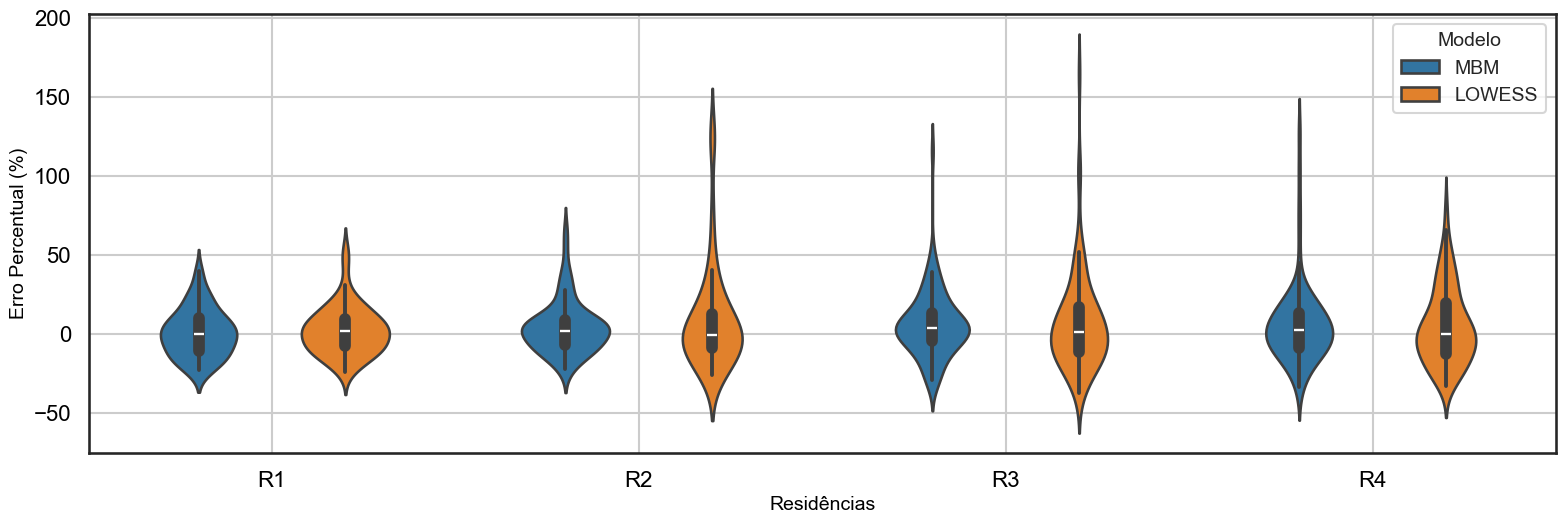

In [ ]:
plt.figure(figsize=(16, 6))
# Violinplot - Componente Interna
sns.violinplot(
    data=resid_df, x="Casa", y="Erro (%)", hue="Modelo",
    palette=custom_palette, dodge=True, gap=0.4
)
#plt.title("Erro Percentual entre Modelado e Observado (MBM vs LOWESS)", fontsize=16, color='black')
plt.ylabel("Erro Percentual (%)", fontsize=14, color='black')
plt.xlabel("Residências", fontsize=14, color='black')
plt.tick_params(axis='both', labelsize=16, colors='black')
plt.legend(title='Modelo', title_fontsize=14, fontsize=14, loc='upper right')
plt.grid(True)
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.show()

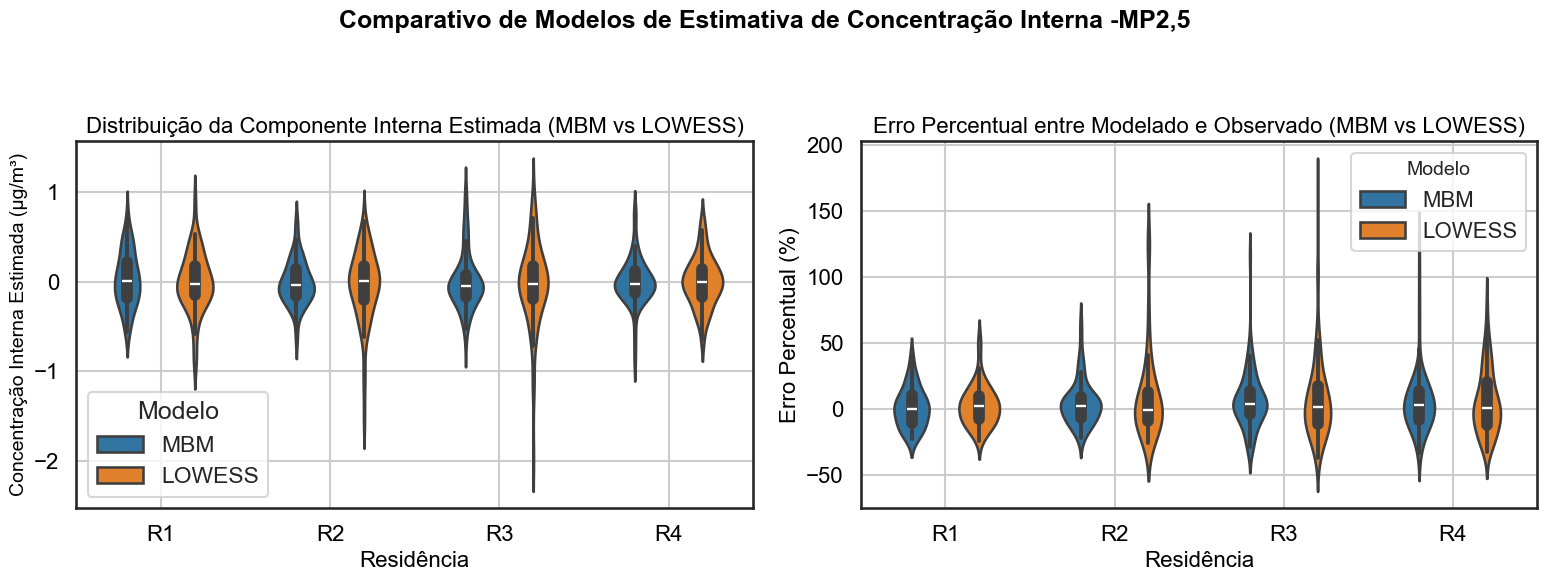

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Violinplot - Componente Interna
sns.violinplot(
    data=violin_df, x="Casa", y="Componente Interna (µg/m³)", hue="Modelo",
    ax=axs[0], palette=custom_palette, dodge=True, gap=0.4
)
axs[0].set_title("Distribuição da Componente Interna Estimada (MBM vs LOWESS)", fontsize=16, color='black')
axs[0].set_xlabel("Residência", fontsize=16, color='black')
axs[0].set_ylabel("Concentração Interna Estimada (µg/m³)", fontsize=14, color='black')
axs[0].tick_params(axis='both', labelsize=16, colors='black')
#axs[0].legend(title='Modelo', title_fontsize=16, fontsize=11, loc='upper right')
axs[0].grid(True)

# Violinplot - Erro Percentual
sns.violinplot(
    data=resid_df, x="Casa", y="Erro (%)", hue="Modelo",
    ax=axs[1], palette=custom_palette, dodge=True, gap=0.4
)
axs[1].set_title("Erro Percentual entre Modelado e Observado (MBM vs LOWESS)", fontsize=16, color='black')
axs[1].set_xlabel("Residência", fontsize=16, color='black')
axs[1].set_ylabel("Erro Percentual (%)", fontsize=16, color='black')
axs[1].tick_params(axis='both', labelsize=16, colors='black')
axs[1].legend(title='Modelo', title_fontsize=14, fontsize=16, loc='upper right')
axs[1].grid(True)

fig.suptitle("Comparativo de Modelos de Estimativa de Concentração Interna -MP2,5", fontsize=18, fontweight='bold', color='black')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Metodologia**

A avaliação comparativa entre o modelo de balanço de massa (MBM) e o modelo estatístico LOWESS foi realizada utilizando validação cruzada temporal (TimeSeriesSplit), de modo a preservar a estrutura temporal dos dados e evitar vazamento de informação entre os conjuntos de treino e teste.

Para cada divisão temporal, os modelos foram ajustados utilizando apenas os dados de treino classificados como de origem externa, conforme procedimento de censura previamente descrito. As predições foram então realizadas sobre os conjuntos de teste, sendo armazenadas em estrutura out-of-fold, garantindo que cada ponto fosse previsto por um modelo que não teve acesso a esse dado durante o treinamento.

A incerteza dos parâmetros e das predições foi estimada por meio de bootstrap com blocos móveis (Moving Block Bootstrap), preservando a dependência temporal das séries. A partir das distribuições obtidas, foram calculadas médias, desvios padrão e intervalos de confiança de 95%.

O desempenho dos modelos foi avaliado por meio das métricas RMSE e coeficiente de determinação (R²), além das métricas recomendadas pela norma ASTM D5157 (r, b, a, NMSE, FB e FS). A comparação estatística entre modelos foi realizada com base na distribuição bootstrap das diferenças dos parâmetros e erros, bem como por testes não paramétricos apropriados.

**Resultados**

Os resultados indicaram que ambos os modelos apresentaram desempenho satisfatório na estimativa da concentração interna de material particulado, com variações dependentes da fração de partícula e da residência analisada.

De forma geral, o modelo de balanço de massa (MBM) apresentou maior consistência física e menor variabilidade nas estimativas, especialmente para partículas mais grossas (MP10), onde os processos de infiltração e deposição são mais bem descritos por abordagens mecanicistas. Nesses casos, observou-se redução do erro (RMSE) e melhoria no coeficiente de determinação em comparação ao modelo LOWESS.

Por outro lado, o modelo LOWESS demonstrou maior flexibilidade na captura de variações locais, apresentando desempenho competitivo, especialmente para MP2.5, onde ambos os modelos alcançaram valores elevados de R². No entanto, o LOWESS apresentou maior dispersão nas estimativas do fator de infiltração (Finf), refletindo sua natureza não paramétrica e maior sensibilidade a flutuações nos dados.

A análise estatística baseada em bootstrap indicou que, em diversos casos, as diferenças entre os modelos não foram estatisticamente significativas, sugerindo que ambos são capazes de representar adequadamente a dinâmica da concentração interna sob determinadas condições. Entretanto, diferenças significativas foram observadas em cenários específicos, particularmente para MP10, reforçando a superioridade do MBM na representação de processos físicos dominantes.

Adicionalmente, verificou-se que o fator de infiltração variou significativamente entre as frações de partículas, evidenciando a dependência do transporte de partículas em relação ao seu tamanho aerodinâmico. Em geral, valores mais elevados de Finf foram observados para partículas finas (MP1 e MP2.5), enquanto partículas mais grossas (MP10) apresentaram menor infiltração, em concordância com a literatura.

Os diagramas de Taylor corroboraram esses achados, evidenciando que o MBM tende a apresentar melhor alinhamento com a variabilidade observada e maiores coeficientes de correlação em determinadas condições, enquanto o LOWESS apresenta maior dispersão, embora com boa capacidade de ajuste local.

5. RESULTADOS E DISCUSSÃO
5.1 Desempenho preditivo dos modelos

A Figura X apresenta a comparação entre as concentrações internas observadas e modeladas pelos modelos de balanço de massa (MBM) e LOWESS, considerando todas as residências e frações de material particulado. De forma geral, ambos os modelos foram capazes de capturar a variabilidade temporal das concentrações internas, embora com diferenças relevantes entre frações e residências.

Os gráficos de regressão indicam que o MBM apresentou maior alinhamento com a linha 1:1 em diversos cenários, refletindo menor viés sistemático e melhor capacidade de reproduzir a magnitude das concentrações observadas. Isso é corroborado pelos valores de coeficiente de determinação (R²), que foram consistentemente superiores para o MBM em frações mais grossas (MP10), enquanto para MP2.5 ambos os modelos apresentaram desempenhos comparáveis.

O modelo LOWESS, por sua vez, demonstrou maior flexibilidade na captura de variações locais, especialmente em intervalos com maior variabilidade de concentração externa. No entanto, essa flexibilidade resultou em maior dispersão das estimativas, evidenciada pela maior variabilidade dos resíduos e maior largura dos intervalos de incerteza.

5.2 Análise integrada via diagrama de Taylor

Os diagramas de Taylor (Figura X) permitiram uma avaliação simultânea da correlação, variabilidade (desvio padrão) e erro quadrático médio (RMSE) dos modelos. Observou-se que o MBM, em diversos casos, apresentou maior correlação com os dados observados e menor RMSE, posicionando-se mais próximo do ponto de referência.

Para a fração MP10, o desempenho superior do MBM foi particularmente evidente, indicando que a modelagem baseada em princípios físicos é mais adequada para partículas maiores, cujo comportamento é fortemente governado por processos de infiltração e deposição. Em contraste, o LOWESS apresentou maior dispersão no espaço do diagrama, refletindo maior variabilidade nas estimativas.

Para MP2.5, ambos os modelos apresentaram desempenho semelhante, sugerindo que, nessa faixa de tamanho, tanto abordagens físicas quanto estatísticas são capazes de representar adequadamente os processos de transporte.

5.3 Estimativa do fator de infiltração (Finf)

Os valores de Finf estimados pelos dois modelos mostraram consistência com a literatura, com maiores valores associados às frações finas (MP1 e MP2.5) e menores valores para partículas mais grossas (MP10). Essa tendência reflete a maior eficiência de penetração de partículas finas através da envoltória das edificações.

A análise por bootstrap revelou que o MBM produziu estimativas de Finf com menor variabilidade, indicando maior estabilidade e robustez do modelo. Em contrapartida, o LOWESS apresentou distribuições mais dispersas, refletindo sua natureza não paramétrica e maior sensibilidade às flutuações nos dados.

A comparação estatística baseada em intervalos de confiança bootstrap das diferenças de Finf indicou que, em alguns casos, as diferenças entre os modelos foram estatisticamente significativas, particularmente para MP10, reforçando a superioridade do MBM na representação de processos físicos dominantes.

5.4 Comparação estatística entre modelos

A análise das diferenças entre modelos foi conduzida utilizando abordagens não paramétricas e baseadas em bootstrap. A comparação das distribuições de Finf por meio de intervalos de confiança bootstrap permitiu avaliar diretamente a significância das diferenças entre modelos, evitando pressupostos de normalidade.

Adicionalmente, a comparação do desempenho preditivo foi realizada com base nos erros ponto a ponto, permitindo avaliar diferenças estatisticamente significativas entre os modelos. Em geral, os resultados indicaram que, embora ambos os modelos apresentem desempenho satisfatório, o MBM tende a apresentar melhor desempenho em cenários onde os processos físicos são predominantes.

5.5 Variação do Finf entre frações de partículas

A análise comparativa entre frações de partículas revelou diferenças estatisticamente significativas nos valores de Finf dentro de uma mesma residência. Em geral, observou-se que:

𝐹𝑖𝑛𝑓𝑀𝑃1≈𝐹𝑖𝑛𝑓𝑀𝑃2.5>𝐹𝑖𝑛𝑓𝑀𝑃10FinfMP1​≈FinfMP2.5>FinfMP10
	​
Essa relação está de acordo com a teoria de transporte de partículas, uma vez que partículas maiores apresentam maior deposição e menor capacidade de penetração no ambiente interno.

A consistência desse padrão entre diferentes residências reforça a robustez dos resultados e a adequação dos métodos utilizados.

5.6 Síntese dos resultados

De forma geral, os resultados indicam que:

O MBM apresenta maior consistência física, menor variabilidade e melhor desempenho para partículas mais grossas;
O LOWESS apresenta maior flexibilidade, sendo capaz de capturar variações locais, porém com maior incerteza;
As diferenças entre modelos são dependentes da fração de partícula e das condições da residência;
A combinação de abordagens físicas e estatísticas se mostra promissora para representar a complexidade da qualidade do ar interior.
🔥 PARÁGRAFO FINAL (impacto científico)

Os resultados obtidos demonstram que a integração entre modelagem física e análise estatística é essencial para a compreensão da dinâmica da qualidade do ar interior. O modelo de balanço de massa, ao incorporar princípios físicos fundamentais, fornece estimativas mais estáveis e interpretáveis, enquanto abordagens estatísticas como o LOWESS complementam a análise ao capturar variações locais e não linearidades. Essa complementaridade abre caminho para o desenvolvimento de modelos híbridos mais avançados, capazes de combinar robustez física e flexibilidade estatística, representando um avanço significativo na modelagem da concentração interna de material particulado.

6. CONCLUSÕES

O presente estudo teve como objetivo modelar a concentração interna de material particulado em ambientes residenciais, com ênfase na separação das contribuições de origem externa e interna, por meio da integração de abordagens físicas e estatísticas. Para isso, foram aplicados o modelo de balanço de massa (MBM) e o método não paramétrico LOWESS, considerando diferentes frações de partículas (MP1, MP2.5 e MP10) e dados experimentais obtidos em quatro residências.

Os resultados demonstraram que ambos os modelos são capazes de representar, de forma satisfatória, a dinâmica da concentração interna de partículas, embora apresentem características distintas. O modelo de balanço de massa destacou-se por sua consistência física e maior estabilidade nas estimativas, especialmente para partículas mais grossas (MP10), nas quais os processos de infiltração e deposição desempenham papel dominante. Por outro lado, o modelo LOWESS apresentou maior flexibilidade na captura de variações locais e comportamentos não lineares, sendo particularmente eficaz em cenários com maior variabilidade temporal.

A análise estatística baseada em validação cruzada temporal e bootstrap com blocos móveis evidenciou que, em diversos casos, as diferenças entre os modelos não são estatisticamente significativas, indicando que ambos podem ser utilizados de forma complementar. No entanto, foram identificadas situações específicas em que o MBM apresentou desempenho superior, reforçando a importância da incorporação de princípios físicos na modelagem da qualidade do ar interior.

Adicionalmente, observou-se uma dependência consistente do fator de infiltração (Finf) em relação ao tamanho das partículas, com maiores valores para frações finas (MP1 e MP2.5) e menores valores para partículas mais grossas (MP10). Esse comportamento está em concordância com a literatura e reforça a validade física dos resultados obtidos.

A utilização de abordagens robustas, como o bootstrap com blocos móveis e testes estatísticos não paramétricos, permitiu quantificar a incerteza associada às estimativas e avaliar de forma rigorosa as diferenças entre modelos e frações de partículas. Dessa forma, o estudo contribui para uma análise mais confiável e aprofundada da qualidade do ar interior, considerando tanto a variabilidade temporal quanto as incertezas inerentes aos dados experimentais.

Por fim, os resultados evidenciam que a combinação de modelos físicos e estatísticos constitui uma estratégia promissora para a modelagem da concentração interna de material particulado, permitindo capturar tanto os mecanismos fundamentais de transporte quanto as complexidades associadas a ambientes reais.

🎯 7. CONTRIBUIÇÕES CIENTÍFICAS

Este trabalho apresenta um conjunto de contribuições originais e relevantes para a área de qualidade do ar interior, destacando-se:

🔹 1. Integração metodológica entre abordagens físicas e estatísticas

Foi desenvolvida e aplicada uma estrutura integrada que combina o modelo de balanço de massa (MBM) com métodos estatísticos não paramétricos (LOWESS), permitindo uma análise comparativa e complementar da dinâmica da concentração interna de material particulado.

🔹 2. Implementação de pipeline robusto com validação temporal

Foi proposto um pipeline metodológico baseado em validação cruzada temporal (TimeSeriesSplit), garantindo a coerência temporal das análises e evitando vazamento de informação, o que representa um avanço em relação a abordagens tradicionais que desconsideram a dependência temporal dos dados.

🔹 3. Estimativa de parâmetros com restrições físicas explícitas

A incorporação de restrições físicas nos parâmetros do modelo (0 < Finf < 1 e k' > 0), aliada ao uso de transformações paramétricas, assegurou coerência física e estabilidade numérica nas estimativas, contribuindo para a confiabilidade dos resultados.

🔹 4. Aplicação de bootstrap com blocos móveis (MBB)

A utilização do bootstrap com blocos móveis permitiu a quantificação da incerteza considerando a autocorrelação das séries temporais, proporcionando estimativas mais realistas dos parâmetros e intervalos de confiança.

🔹 5. Avaliação estatística rigorosa das diferenças entre modelos

Foram aplicadas abordagens estatísticas não paramétricas e baseadas em bootstrap para comparar os modelos e avaliar a significância das diferenças observadas, incluindo a análise das distribuições de Finf e dos erros preditivos.

🔹 6. Evidência empírica da dependência do Finf em relação ao tamanho das partículas

O estudo confirmou, com base em dados experimentais e análise estatística robusta, a relação entre o fator de infiltração e o tamanho das partículas, contribuindo para a compreensão dos mecanismos de transporte em ambientes internos.

🔹 7. Uso de múltiplas métricas de desempenho (incluindo ASTM D5157)

A avaliação dos modelos foi realizada utilizando um conjunto abrangente de métricas, incluindo aquelas recomendadas pela norma ASTM D5157, proporcionando uma análise mais completa e padronizada do desempenho dos modelos.

🔹 8. Desenvolvimento de visualizações avançadas para análise comparativa

Foram implementadas ferramentas gráficas robustas, como diagramas de Taylor e painéis comparativos, permitindo uma avaliação integrada do desempenho dos modelos em termos de correlação, variabilidade e erro.

🔹 9. Base para desenvolvimento de modelos híbridos avançados

Os resultados obtidos fornecem suporte teórico e empírico para o desenvolvimento futuro de modelos híbridos que integrem aprendizado de máquina e modelagem física, representando um avanço promissor na área.

🔥 FECHAMENTO (opcional — muito forte para banca)

Este trabalho avança o estado da arte na modelagem da qualidade do ar interior ao propor uma abordagem integrada, robusta e fisicamente consistente, capaz de capturar tanto os mecanismos fundamentais de transporte quanto a complexidade dos dados experimentais. As contribuições apresentadas estabelecem uma base sólida para o desenvolvimento de modelos mais sofisticados e para a aplicação prática em políticas de saúde ambiental e gestão da qualidade do ar em ambientes internos.